## Импорты

In [ ]:
!pip install pygwalker --quiet
# !pip install gdown
!pip install google

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 956.2/956.2 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 92.6 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
import pandas as pd
import pygwalker as pyg
import os
from google.colab import drive


from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload
from google.colab import auth
import google.auth
import datetime
import re
import matplotlib.pyplot as plt
import gdown
import seaborn as sns
import numpy as np

In [ ]:
FOLDER_ID = "1aoMxqBCuux2i9jBTjEmmopVfOYzYOgR-"
DATA_DIR = Path("drive_data")
dataframes = {}

url = f"https://drive.google.com/drive/folders/{FOLDER_ID}"
with_recreate_dir = (
    False  # Установите True если хотите пересоздать папку и перезалить данные
)

if with_recreate_dir:
    # Полностью удаляем папку и пересоздаём ее
    import shutil

    if DATA_DIR.exists():
        shutil.rmtree(DATA_DIR)
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    gdown.download_folder(url, output=str(DATA_DIR), quiet=False, use_cookies=False)
elif not DATA_DIR.exists() or not any(DATA_DIR.glob("*.csv")):
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    gdown.download_folder(url, output=str(DATA_DIR), quiet=False, use_cookies=False)

for csv_path in sorted(DATA_DIR.glob("*.csv")):
    df = pd.read_csv(csv_path)
    var_name = os.path.splitext(csv_path)[0]
    # Обрезаем 'drive_data/' из имени файла для переменной var_name
    cleaned_var_name = os.path.splitext(os.path.basename(csv_path))[0]
    dataframes[cleaned_var_name] = df
    print(f"Файл '{csv_path}' успешно загружен. Размер: {df.shape}")

print("Имена файлов:", list(dataframes.keys()))

Retrieving folder contents


Retrieving folder 1pf7F__1ZCMtMGbjkGr1NsLss7vO7zkOk MERGED_DATA
Processing file 1IBm6hhFlOIK-qDzWsJK3F7lbdMRgyi68l3kxU-HudTw 2026-04-14_10-07-21_k_9602585349_merged_dataframe
Processing file 1AKhvQUMH67KDt4Ku49DYOBHaFM_CmrLF 2026-04-14_10-07-21_k_9602585349_merged_dataframe.csv
Processing file 1GPlddnDlJ2TmStdMPx-WqYpDvOaV43tp 2026-04-14_10-27-53_k_9602585349_merged_dataframe.csv
Processing file 1MJwsgC3MY49sM3SD7j5mfH4A3v8Pg-w9 2026-04-14_18-13-32_k_9602585349_merged_dataframe.csv
Processing file 1EV3NG6G0gTtNXEnhwEsGJSJjNJA_RBSO award_badges.csv
Processing file 1oPdVpIt4ilnJZLgEcs9yRkAzTMcMWUPo groups.csv
Processing file 17sOJGbkRvPnZFgEzfBv_VINQwflgNKom homework_items.csv
Processing file 1GELk6igR8TZYotN4rNLAre5mzTttVznN homeworks.csv
Processing file 1O49lBqVGhqMsYZAYntnHUOq3ubAGdpS5 lesson_tasks.csv
Processing file 1NYR7kcv8RVegAGjaqg0b1ZOuWGQVVyF6 lessons.csv
Processing file 1bVPuK9Ppnk91FvkWrLs63GXzRoaMC905 stats__module_1.csv
Processing file 1X3I2C4Wfv7Ozv1fo418ajIWUdwEDps7Q sta

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1IBm6hhFlOIK-qDzWsJK3F7lbdMRgyi68l3kxU-HudTw
From (redirected): https://docs.google.com/spreadsheets/d/1IBm6hhFlOIK-qDzWsJK3F7lbdMRgyi68l3kxU-HudTw/export?format=xlsx
To: /content/drive_data/MERGED_DATA/2026-04-14_10-07-21_k_9602585349_merged_dataframe
20.6MB [00:00, 90.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1AKhvQUMH67KDt4Ku49DYOBHaFM_CmrLF
To: /content/drive_data/MERGED_DATA/2026-04-14_10-07-21_k_9602585349_merged_dataframe.csv
100%|██████████| 29.2M/29.2M [00:00<00:00, 108MB/s]
Downloading...
From: https://drive.google.com/uc?id=1GPlddnDlJ2TmStdMPx-WqYpDvOaV43tp
To: /content/drive_data/MERGED_DATA/2026-04-14_10-27-53_k_9602585349_merged_dataframe.csv
100%|██████████| 29.2M/29.2M [00:00<00:00, 77.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1MJwsgC3MY49sM3SD7j5mfH4A3v8Pg-w9
To: /conten

Файл 'drive_data/award_badges.csv' успешно загружен. Размер: (6, 8)
Файл 'drive_data/groups.csv' успешно загружен. Размер: (13076, 13)
Файл 'drive_data/homework_items.csv' успешно загружен. Размер: (5901, 6)
Файл 'drive_data/homeworks.csv' успешно загружен. Размер: (1226, 5)
Файл 'drive_data/lesson_tasks.csv' успешно загружен. Размер: (29544, 6)
Файл 'drive_data/lessons.csv' успешно загружен. Размер: (3369, 13)
Файл 'drive_data/stats__module_1.csv' успешно загружен. Размер: (3261, 19)
Файл 'drive_data/stats__module_2.csv' успешно загружен. Размер: (1955, 20)
Файл 'drive_data/stats__module_3.csv' успешно загружен. Размер: (1785, 19)
Файл 'drive_data/stats__module_4.csv' успешно загружен. Размер: (1707, 18)
Файл 'drive_data/trainings.csv' успешно загружен. Размер: (410, 9)
Файл 'drive_data/user_activity_histories.csv' успешно загружен. Размер: (3031137, 4)
Файл 'drive_data/user_answers.csv' успешно загружен. Размер: (15176182, 15)
Файл 'drive_data/user_award_badges.csv' успешно загружен.

/tmp/ipykernel_10388/794605077.py:23: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


Файл 'drive_data/users.csv' успешно загружен. Размер: (95395, 22)


/tmp/ipykernel_10388/794605077.py:23: DtypeWarning: Columns (9,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


Файл 'drive_data/users_courses.csv' успешно загружен. Размер: (290835, 14)
Файл 'drive_data/wk_media_view_sessions.csv' успешно загружен. Размер: (852358, 8)


/tmp/ipykernel_10388/794605077.py:23: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


Файл 'drive_data/wk_users_courses_actions.csv' успешно загружен. Размер: (12909207, 8)
Имена файлов: ['award_badges', 'groups', 'homework_items', 'homeworks', 'lesson_tasks', 'lessons', 'stats__module_1', 'stats__module_2', 'stats__module_3', 'stats__module_4', 'trainings', 'user_activity_histories', 'user_answers', 'user_award_badges', 'user_lessons', 'user_trainings', 'users', 'users_courses', 'wk_media_view_sessions', 'wk_users_courses_actions']


## Первичный анализ

In [ ]:
# Удалить столбцы, содержащие 'Unnamed', во всех датафреймах, начинающихся с df_
for name in dataframes.keys():
    cols_to_drop = [
        col for col in dataframes[name].columns if col.startswith("Unnamed")
    ]
    if cols_to_drop:
        dataframes[name] = dataframes[name].drop(columns=cols_to_drop)

# Колонки, помеченные как "ненужное поле" в tables_description.pdf
drop_map = {
    "user_answers": [
        "performance",
    ],
    "wk_users_courses_actions": [
        "sourceable_id",
    ],
    "award_badges": [
        "name",
    ],
    "users": [
        "remember_created_at",
        "current_sign_in_at",
        "grade_changed_at",
        "last_sign_in_at",
        "grade_checked",
        "xp",
        "d_wk_municipal_id",
        "d_wk_region_id",
        "d_updated_at",
        "last_explainer_seen_→_course",
    ],
}

# Удаляем безопасно (если колонка/датафрейм отсутствуют — без ошибки)
for name in dataframes.keys():
    if name in drop_map.keys():
        dataframes[name] = dataframes[name].drop(
            columns=drop_map[name], errors="ignore"
        )

## EDA

Очистка данных

### award_badges


### user_award_badges
не требуется

### user_answers

In [ ]:
ua = dataframes["user_answers"].copy()
_n0 = len(ua)


def _strip_id_series(s: pd.Series) -> pd.Series:
    return (
        s.astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
        .replace({"nan": pd.NA, "None": pd.NA, "<NA>": pd.NA})
    )


for col in ("user_id", "task_id", "resource_id"):
    if col in ua.columns:
        ua[col] = pd.to_numeric(_strip_id_series(ua[col]), errors="coerce").astype("Int64")

if "submitted_at" in ua.columns:
    ua["submitted_at"] = pd.to_datetime(ua["submitted_at"], errors="coerce")

# Строки без ключевых идентификаторов отбрасываем
ua = ua.dropna(subset=["user_id", "task_id"])
_n1 = len(ua)
print(f"После dropna(user_id, task_id): {_n0} -> {_n1} (удалено {_n0 - _n1})")

# только ответы пользователей из актуального справочника users
_before_users = len(ua)
ua = ua[ua["user_id"].isin(dataframes["users"]["id"])]
print(f"После фильтра по dataframes['users']['id']: {_before_users} -> {len(ua)} (отброшено {_before_users - len(ua)})")

ua = ua.reset_index(drop=True)
dataframes["user_answers"] = ua
print("Итог user_answers:", dataframes["user_answers"].shape, dataframes["user_answers"].dtypes.to_string())

После dropna(user_id, task_id): 15176182 -> 15176182 (удалено 0)
После фильтра по dataframes['users']['id']: 15176182 -> 15176062 (отброшено 120)
Итог user_answers: (15176062, 13) user_id                        Int64
task_id                        Int64
attempts                       int64
solved                        object
points                       float64
max_attempts                   int64
results                       object
skipped                       object
resource_type                 object
resource_id                    Int64
submitted_at          datetime64[ns]
wk_partial_answer             object
async_check_status             int64


### groups


In [ ]:
groups = dataframes["groups"].copy()

groups_clean = groups.copy()

# убрать технический столбец
if "Unnamed: 0" in groups_clean.columns:
    groups_clean = groups_clean.drop(columns=["Unnamed: 0"])

# datetime
date_cols = [
    "starts_at",
    "pupils_notified_at",
    "wk_actual_started_at",
    "wk_actual_finished_at",
]
for col in date_cols:
    groups_clean[col] = pd.to_datetime(groups_clean[col], errors="coerce")

# удалить явно дефектные строки
bad_mask = (
    (
        groups_clean["starts_at"].notna() &
        groups_clean["wk_actual_finished_at"].notna() &
        (groups_clean["starts_at"] > groups_clean["wk_actual_finished_at"])
    )
    |
    (groups_clean["duration"] <= 0)
)

print("bad rows to drop:", bad_mask.sum())

groups_clean = groups_clean.loc[~bad_mask].copy()

print("clean shape:", groups_clean.shape)
print("full_duplicates:", groups_clean.duplicated().sum())
print("duplicate id rows:", groups_clean.duplicated(subset=["id"], keep=False).sum())

groups = groups_clean.copy()

bad rows to drop: 9
clean shape: (13067, 12)
full_duplicates: 0
duplicate id rows: 0


Таблица `groups` после удаления технического столбца `Unnamed: 0`:
- полных дублей не было;
- `id` был уникален.

Основные проблемы были не структурными, а логическими:
- обнаружены строки, где `starts_at > wk_actual_finished_at`;
- обнаружена строка с `duration <= 0`.

Всего выявлено `9` явно дефектных записей. Эти строки были удалены как логически противоречивые.

Также поля
- `starts_at`,
- `pupils_notified_at`,
- `wk_actual_started_at`,
- `wk_actual_finished_at`

были приведены к типу `datetime`.

После очистки:
- противоречий по временам не осталось;
- неположительной длительности не осталось;
- полных дублей и дублей по `id` нет.

Итоговая форма очищенной таблицы: `(13067, 12)`.

### homework_items


In [ ]:
homework_items = dataframes["homework_items"].copy()

homework_items_clean = homework_items.copy()

# Удаляем технический столбец
if "Unnamed: 0" in homework_items_clean.columns:
    homework_items_clean = homework_items_clean.drop(columns=["Unnamed: 0"])

# Базовая структура
print("shape:", homework_items_clean.shape)
print("\ndtypes before cleaning:")
print(homework_items_clean.dtypes)

print("\nfull_duplicates:", homework_items_clean.duplicated().sum())
print("duplicate id rows:", homework_items_clean.duplicated(subset=["id"], keep=False).sum())

# Проверка пропусков
miss = (
    homework_items_clean.isna().sum()
    .to_frame("null_count")
    .assign(null_pct=lambda x: (x["null_count"] / len(homework_items_clean) * 100).round(4))
    .query("null_count > 0")
    .sort_values(["null_count", "null_pct"], ascending=False)
)

print("\nmissing values:")
display(miss if len(miss) else pd.DataFrame({"message": ["no nulls"]}))

# Проверка категориальных значений
print("\nresource_type value_counts:")
print(homework_items_clean["resource_type"].value_counts(dropna=False))

# Проверка ключевых дублей и порядка
print("\nduplicate (homework_id, resource_id) rows:")
print(homework_items_clean.duplicated(subset=["homework_id", "resource_id"], keep=False).sum())

print("\nduplicate (homework_id, position) rows:")
print(homework_items_clean.duplicated(subset=["homework_id", "position"], keep=False).sum())

print("\nposition min/max:", homework_items_clean["position"].min(), homework_items_clean["position"].max())
print("position <= 0:", (homework_items_clean["position"] <= 0).sum())

# Проверка приведения id к числам
homework_items_tmp = homework_items_clean.copy()
homework_items_tmp["homework_id_num"] = pd.to_numeric(
    homework_items_tmp["homework_id"].astype(str).str.replace(",", "", regex=False),
    errors="coerce"
)
homework_items_tmp["resource_id_num"] = pd.to_numeric(
    homework_items_tmp["resource_id"].astype(str).str.replace(",", "", regex=False),
    errors="coerce"
)

print("\nhomework_id -> numeric NaN:", homework_items_tmp["homework_id_num"].isna().sum())
print("resource_id -> numeric NaN:", homework_items_tmp["resource_id_num"].isna().sum())

# Показываем строки с конфликтом позиций внутри одного homework_id
homework_items_bad_pos = homework_items_clean[
    homework_items_clean.duplicated(subset=["homework_id", "position"], keep=False)
].sort_values(["homework_id", "position", "resource_id"])

print("\nrows with duplicated (homework_id, position):", homework_items_bad_pos.shape[0])
display(homework_items_bad_pos)

# Финальная очистка
homework_items_clean["homework_id"] = (
    homework_items_clean["homework_id"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype("int64")
)

homework_items_clean["resource_id"] = (
    homework_items_clean["resource_id"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype("int64")
)

print("\nFinal cleaned table")
print("shape:", homework_items_clean.shape)
print("\ndtypes after cleaning:")
print(homework_items_clean.dtypes)

print("\nfull_duplicates:", homework_items_clean.duplicated().sum())
print("duplicate id rows:", homework_items_clean.duplicated(subset=["id"], keep=False).sum())
print(
    "duplicate (homework_id, resource_id) rows:",
    homework_items_clean.duplicated(subset=["homework_id", "resource_id"], keep=False).sum()
)
print(
    "duplicate (homework_id, position) rows:",
    homework_items_clean.duplicated(subset=["homework_id", "position"], keep=False).sum()
)
print("position <= 0:", (homework_items_clean["position"] <= 0).sum())

homework_items = homework_items_clean.copy()

shape: (5901, 5)

dtypes before cleaning:
id                int64
homework_id      object
resource_type    object
resource_id      object
position          int64
dtype: object

full_duplicates: 0
duplicate id rows: 0

missing values:


,message
0,no nulls



resource_type value_counts:
resource_type
Task          5895
CommonFile       5
Video            1
Name: count, dtype: int64

duplicate (homework_id, resource_id) rows:
0

duplicate (homework_id, position) rows:
2

position min/max: 1 34
position <= 0: 0

homework_id -> numeric NaN: 0
resource_id -> numeric NaN: 0

rows with duplicated (homework_id, position): 2


,id,homework_id,resource_type,resource_id,position
5171,5798,"1,643",CommonFile,"2,301",2
5176,5799,"1,643",CommonFile,"2,302",2



Final cleaned table
shape: (5901, 5)

dtypes after cleaning:
id                int64
homework_id       int64
resource_type    object
resource_id       int64
position          int64
dtype: object

full_duplicates: 0
duplicate id rows: 0
duplicate (homework_id, resource_id) rows: 0
duplicate (homework_id, position) rows: 2
position <= 0: 0


1. Удален технический столбец `Unnamed: 0`.
2. Проверены:
   - форма таблицы;
   - типы данных;
   - полные дубли;
   - уникальность `id`;
   - пропуски;
   - распределение `resource_type`;
   - дубли по `(homework_id, resource_id)`;
   - дубли по `(homework_id, position)`;
   - корректность значений `position`.
3. Поля `homework_id` и `resource_id` очищены от форматирующих запятых и приведены к типу `int64`.

Что показала проверка

- Таблица структурно чистая:
  - полных дублей нет;
  - `id` уникален;
  - пропусков нет.
- Поля `homework_id` и `resource_id` полностью приводятся к числовому типу без потерь.
- Дублей по паре `(homework_id, resource_id)` нет.
- Поле `position` всегда положительно.

Выявленная логическая аномалия

Обнаружены `2` строки, в которых внутри одного и того же `homework_id` повторяется одна и та же позиция:
- `homework_id = 1643`,
- `position = 2`.

При этом это не технические дубли:
- `id` разные,
- `resource_id` разные,
- обе строки относятся к `resource_type = CommonFile`.

Следовательно, это локальная коллизия порядка элементов внутри одного домашнего задания, а не повтор одной и той же записи.

### homeworks


In [ ]:
homeworks = dataframes["homeworks"].copy()

homeworks_clean = homeworks.copy()

# Удаляем технический столбец
if "Unnamed: 0" in homeworks_clean.columns:
    homeworks_clean = homeworks_clean.drop(columns=["Unnamed: 0"])

# Базовая структура
print("shape:", homeworks_clean.shape)
print("\ndtypes before cleaning:")
print(homeworks_clean.dtypes)

print("\nfull_duplicates:", homeworks_clean.duplicated().sum())
print("duplicate id rows:", homeworks_clean.duplicated(subset=["id"], keep=False).sum())

# Проверка пропусков
miss = (
    homeworks_clean.isna().sum()
    .to_frame("null_count")
    .assign(null_pct=lambda x: (x["null_count"] / len(homeworks_clean) * 100).round(4))
    .query("null_count > 0")
    .sort_values(["null_count", "null_pct"], ascending=False)
)

print("\nmissing values:")
display(miss if len(miss) else pd.DataFrame({"message": ["no nulls"]}))

# Проверка категориальных значений
print("\nresource_type value_counts:")
print(homeworks_clean["resource_type"].value_counts(dropna=False))

print("\nhomework_type value_counts:")
print(homeworks_clean["homework_type"].value_counts(dropna=False).sort_index())

# 5. Проверка дублей по бизнес-ключу
print("\nduplicate (resource_type, resource_id) rows:")
print(homeworks_clean.duplicated(subset=["resource_type", "resource_id"], keep=False).sum())

homeworks_dup_resource = homeworks_clean[
    homeworks_clean.duplicated(subset=["resource_type", "resource_id"], keep=False)
].sort_values(["resource_type", "resource_id", "id"])

print("\nrows with duplicated (resource_type, resource_id):", homeworks_dup_resource.shape[0])
display(homeworks_dup_resource)

dup_profile = (
    homeworks_dup_resource
    .groupby(["resource_type", "resource_id"])
    .agg(
        n_rows=("id", "size"),
        n_id=("id", "nunique"),
        n_homework_type=("homework_type", "nunique"),
    )
    .reset_index()
    .sort_values(["n_rows", "n_homework_type"], ascending=False)
)

print("\nduplicate resource profile:")
display(dup_profile)

# Проверка приведения resource_id к числу
homeworks_tmp = homeworks_clean.copy()
homeworks_tmp["resource_id_num"] = pd.to_numeric(
    homeworks_tmp["resource_id"].astype(str).str.replace(",", "", regex=False),
    errors="coerce"
)

print("\nresource_id -> numeric NaN:", homeworks_tmp["resource_id_num"].isna().sum())

# Финальная очистка
homeworks_clean["resource_id"] = (
    homeworks_clean["resource_id"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype("int64")
)

print("\nFinal cleaned table")
print("shape:", homeworks_clean.shape)
print("\ndtypes after cleaning:")
print(homeworks_clean.dtypes)

print("\nfull_duplicates:", homeworks_clean.duplicated().sum())
print("duplicate id rows:", homeworks_clean.duplicated(subset=["id"], keep=False).sum())
print(
    "duplicate (resource_type, resource_id) rows:",
    homeworks_clean.duplicated(subset=["resource_type", "resource_id"], keep=False).sum()
)

homeworks = homeworks_clean.copy()

shape: (1226, 4)

dtypes before cleaning:
id                int64
resource_type    object
resource_id      object
homework_type     int64
dtype: object

full_duplicates: 0
duplicate id rows: 0

missing values:


,message
0,no nulls



resource_type value_counts:
resource_type
Lesson            1207
LessonMaterial      18
Event                1
Name: count, dtype: int64

homework_type value_counts:
homework_type
1    1208
2       9
3       9
Name: count, dtype: int64

duplicate (resource_type, resource_id) rows:
18

rows with duplicated (resource_type, resource_id): 18


,id,resource_type,resource_id,homework_type
874,1416,LessonMaterial,"1,112",3
876,1419,LessonMaterial,"1,112",2
875,1417,LessonMaterial,"1,113",3
873,1418,LessonMaterial,"1,113",2
877,1420,LessonMaterial,"1,117",3
880,1421,LessonMaterial,"1,117",2
881,1422,LessonMaterial,"1,153",3
882,1423,LessonMaterial,"1,153",2
886,1426,LessonMaterial,"1,155",3
887,1427,LessonMaterial,"1,155",2



duplicate resource profile:


,resource_type,resource_id,n_rows,n_id,n_homework_type
0,LessonMaterial,"1,112",2,2,2
1,LessonMaterial,"1,113",2,2,2
2,LessonMaterial,"1,117",2,2,2
3,LessonMaterial,"1,153",2,2,2
4,LessonMaterial,"1,155",2,2,2
5,LessonMaterial,"1,157",2,2,2
6,LessonMaterial,"6,404",2,2,2
7,LessonMaterial,"6,405",2,2,2
8,LessonMaterial,"7,391",2,2,2



resource_id -> numeric NaN: 0

Final cleaned table
shape: (1226, 4)

dtypes after cleaning:
id                int64
resource_type    object
resource_id       int64
homework_type     int64
dtype: object

full_duplicates: 0
duplicate id rows: 0
duplicate (resource_type, resource_id) rows: 18


1. Удален технический столбец `Unnamed: 0`.
2. Проверены:
   - форма таблицы;
   - типы данных;
   - полные дубли;
   - уникальность `id`;
   - пропуски;
   - распределения `resource_type` и `homework_type`;
   - повторы по паре `(resource_type, resource_id)`.
3. Поле `resource_id` очищено от форматирующих запятых и приведено к типу `int64`.

Что показала проверка

- Таблица имеет корректную структуру.
- Полных дублей нет.
- `id` уникален.
- Пропусков нет.
- `resource_id` полностью приводится к числовому типу без потерь.

Особенность таблицы

Были обнаружены строки с повтором пары `(resource_type, resource_id)`.  
 это **не технические дубли**:

- все такие случаи относятся к `resource_type = LessonMaterial`;
- для одного и того же `resource_id` существуют две разные записи;
- они имеют разные `id`;
- и различаются по `homework_type` (`2` и `3`).

Следовательно, эти строки отражают разные сущности домашних заданий, привязанные к одному и тому же материалу урока, и удалять их нельзя.

### lessons


### lesson_tasks

In [ ]:
lesson_tasks = dataframes["lesson_tasks"].copy()

lesson_tasks_clean = lesson_tasks.copy()

# Удаляем технический столбец
if "Unnamed: 0" in lesson_tasks_clean.columns:
    lesson_tasks_clean = lesson_tasks_clean.drop(columns=["Unnamed: 0"])

# Приводим идентификаторы к числовому виду
lesson_tasks_clean["lesson_id"] = (
    lesson_tasks_clean["lesson_id"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype("int64")
)

lesson_tasks_clean["task_id"] = (
    lesson_tasks_clean["task_id"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype("int64")
)

# Базовые проверки структуры
print("shape:", lesson_tasks_clean.shape)
print("\ndtypes:")
print(lesson_tasks_clean.dtypes)

print("\nfull_duplicates:", lesson_tasks_clean.duplicated().sum())
print("duplicate id rows:", lesson_tasks_clean.duplicated(subset=["id"], keep=False).sum())
print(
    "duplicate (lesson_id, task_id) rows:",
    lesson_tasks_clean.duplicated(subset=["lesson_id", "task_id"], keep=False).sum()
)

# Проверка пропусков
miss = (
    lesson_tasks_clean.isna().sum()
    .to_frame("null_count")
    .assign(null_pct=lambda x: (x["null_count"] / len(lesson_tasks_clean) * 100).round(4))
    .query("null_count > 0")
    .sort_values(["null_count", "null_pct"], ascending=False)
)

print("\nmissing values:")
display(miss if len(miss) else pd.DataFrame({"message": ["no nulls"]}))

# Проверка position
print("\nposition min/max:", lesson_tasks_clean["position"].min(), lesson_tasks_clean["position"].max())
print("position <= 0:", (lesson_tasks_clean["position"] <= 0).sum())

# Логическая проверка порядка задач внутри уроков
dup_pos_rows = lesson_tasks_clean.duplicated(subset=["lesson_id", "position"], keep=False).sum()
print("\nduplicate (lesson_id, position) rows:", dup_pos_rows)

lesson_pos_summary = (
    lesson_tasks_clean
    .groupby("lesson_id")
    .agg(
        n_tasks=("task_id", "size"),
        pos_min=("position", "min"),
        pos_max=("position", "max"),
        pos_nunique=("position", "nunique"),
    )
    .reset_index()
)

lesson_pos_summary["has_gap_or_repeat"] = (
    lesson_pos_summary["pos_max"] - lesson_pos_summary["pos_min"] + 1
    != lesson_pos_summary["pos_nunique"]
)
lesson_pos_summary["starts_not_from_1"] = lesson_pos_summary["pos_min"] != 1

print("lessons with starts_not_from_1:", lesson_pos_summary["starts_not_from_1"].sum())
print("lessons with gap_or_repeat_in_positions:", lesson_pos_summary["has_gap_or_repeat"].sum())

# Точечная аномалия по повтору позиции внутри урока
lesson_tasks_bad_pos = lesson_tasks_clean[
    lesson_tasks_clean.duplicated(subset=["lesson_id", "position"], keep=False)
].sort_values(["lesson_id", "position", "task_id"])

print("\nrows with duplicated position inside lesson:", lesson_tasks_bad_pos.shape[0])
display(lesson_tasks_bad_pos)


# таблицу оставляем целиком, потому что аномалия локальная и требует предметного решения
print("\nFinal cleaned shape:", lesson_tasks_clean.shape)

lesson_tasks = lesson_tasks_clean.copy()

shape: (29544, 5)

dtypes:
id               int64
lesson_id        int64
task_id          int64
position         int64
task_required     bool
dtype: object

full_duplicates: 0
duplicate id rows: 0
duplicate (lesson_id, task_id) rows: 0

missing values:


,message
0,no nulls



position min/max: 1 38
position <= 0: 0

duplicate (lesson_id, position) rows: 6
lessons with starts_not_from_1: 0
lessons with gap_or_repeat_in_positions: 0

rows with duplicated position inside lesson: 6


,id,lesson_id,task_id,position,task_required
2213,2682,561,1111267,2,True
2214,2683,561,1111268,2,True
2215,2684,561,1111269,3,True
2216,2685,561,1111272,3,True
2218,2690,561,1111289,7,True
2219,2691,561,1111290,7,True



Final cleaned shape: (29544, 5)


Для таблицы `lesson_tasks` была выполнена следующая очистка:

1. Удален технический столбец `Unnamed: 0`.
2. Поля `lesson_id` и `task_id` очищены от форматирующих запятых и приведены к типу `int64`.
3. Проверены полные дубли, уникальность `id` и уникальность пары `(lesson_id, task_id)`.
4. Проверены пропуски и корректность поля `position`.

Результат очистки

Таблица после очистки имеет корректную структуру:
- полных дублей нет;
- `id` уникален;
- пары `(lesson_id, task_id)` уникальны;
- пропусков нет;
- `position` всегда положителен.

Логические проверки

Дополнительно была проверена согласованность порядка заданий внутри уроков:
- нумерация позиций во всех уроках начинается с `1`;
- глобальных дыр в диапазоне позиций не обнаружено.

При этом выявлена точечная аномалия:
- в одном уроке (`lesson_id = 561`) разные задания имеют одинаковые позиции (`2`, `3`, `7`).

Это не является дублем строк и не нарушает уникальность `(lesson_id, task_id)`, но означает локальную несогласованность порядка заданий внутри данного урока.

### stats__module_1


### stats__module_2


### stats__module_3


### stats__module_4


### trainings


### user_trainings

#### Маппинг trainig_id с course_id, определение типа треннинга

In [ ]:
# trainings join lessons -> получаем course_id
t = dataframes["trainings"][["id", "name", "lesson_id"]].copy()
t["training_id"] = t["id"].astype(str).str.replace(",", "").astype(int)
t["lesson_id"] = t["lesson_id"].astype(str).str.replace(",", "")

l = dataframes["lessons"][["id", "course_id"]].copy()
l["lesson_id"] = l["id"].astype(str).str.replace(",", "")
l["course_id"] = l["course_id"].astype(str).str.replace(",", "").astype(int)

trainings_x_courses = t.merge(
    l[["lesson_id", "course_id"]], left_on="lesson_id", right_on="lesson_id", how="left"
)

In [ ]:
# Классификация типа тренинга по имени (для критериев 4, 5, 6)
def classify_training(name):
    if pd.isna(name):
        return "other"
    name_lower = name.lower()
    if "промежуточная аттестация" in name_lower:
        return "pa"
    elif "текущий контроль" in name_lower:
        return "tk"
    elif "рефлексия" in name_lower:
        return "refl"
    elif "итоговая аттестация" in name_lower or "итоговое тестирование" in name_lower:
        return "ia"
    else:
        return "other"


trainings_x_courses["criteria_type"] = trainings_x_courses["name"].apply(
    classify_training
)

In [ ]:
# Итоговый маппинг тренниг-курс-тип треннинга
training_map = trainings_x_courses[["training_id", "course_id", "criteria_type"]]

print(
    f"training_map: {len(training_map)} записей, с course_id: {training_map['course_id'].notna().sum()}"
)
print(f"По типам:\n{training_map['criteria_type'].value_counts()}")

training_map: 410 записей, с course_id: 252
По типам:
criteria_type
pa       143
tk       129
other     49
refl      49
ia        40
Name: count, dtype: int64


#### Приведение типов, джойн с маппингом

In [ ]:
ut = dataframes["user_trainings"].copy()

# ID Columns
ut["training_id"] = ut["training_id"].astype(str).str.replace(",", "").astype(int)
ut["user_id"] = ut["user_id"].astype(str).str.replace(",", "").astype(int)

# Numeric columns
ut["solved_tasks_count"] = pd.to_numeric(ut["solved_tasks_count"], errors="coerce")
ut["earned_points"] = pd.to_numeric(ut["earned_points"], errors="coerce")
ut["submitted_answers_count"] = pd.to_numeric(
    ut["submitted_answers_count"], errors="coerce"
)
ut["mark"] = pd.to_numeric(ut["mark"], errors="coerce")
ut["attempts"] = pd.to_numeric(ut["attempts"], errors="coerce")

# Datetime columns
ut["started_at"] = pd.to_datetime(ut["started_at"], format="mixed", errors="coerce")
ut["finished_at"] = pd.to_datetime(ut["finished_at"], format="mixed", errors="coerce")
ut["duration_min"] = (ut["finished_at"] - ut["started_at"]).dt.total_seconds() / 60

In [ ]:
# Джойн с маппингом -> получаем course_id и criteria_type
ut = ut.merge(
    training_map,
    left_on="training_id",
    right_on="training_id",
    how="inner",
    suffixes=("", "_map"),
)

# Оставляем только записи с course_id
ut_with_course = ut[ut["course_id"].notna()].copy()

In [ ]:
print(
    f"\nuser_trainings с course_id: {len(ut_with_course)} из {len(dataframes['user_trainings'])}"
)
print(f"\nПо criteria_type:\n{ut_with_course['criteria_type'].value_counts()}")


user_trainings с course_id: 416374 из 427628

По criteria_type:
criteria_type
tk       154702
pa       152427
other     46640
ia        40298
refl      22307
Name: count, dtype: int64


#### Очистка данных

In [ ]:
# duration_min: Клиппинг выбросов по 99-м перцентилю (незакрытые сессии)
p97 = ut_with_course["duration_min"].quantile(0.97)
print(f"\nduration_min p97: {p97:.1f} мин")
ut_with_course["duration_min_clipped"] = ut_with_course["duration_min"].clip(upper=p97)


duration_min p97: 48.0 мин


#### Агрегаты в разрезе user_id & course_id

In [ ]:
agg_user_course = (
    ut_with_course.groupby(["user_id", "course_id"])
    .agg(
        # Общие метрики
        ut_total_trainings_cnt=("state", "count"),
        ut_checked_trainings_pct=("state", lambda x: (x == "checked").mean()),
        # Оценки
        ut_mark_mean=("mark", "mean"),
        ut_mark_ge4_pct=("mark", lambda x: (x >= 4).mean()),
        # Баллы
        ut_points_mean=("earned_points", "mean"),
        # Задачи
        ut_solved_tasks_mean=("solved_tasks_count", "mean"),
        # Время решения (после клиппирования)
        ut_duration_mean=("duration_min_clipped", "mean"),
        # Временные метки
        ut_first_at=("started_at", "min"),
        ut_last_at=("started_at", "max"),
    )
    .reset_index()
)

# Период активности в тренингах
agg_user_course["ut_span_days"] = (
    agg_user_course["ut_last_at"] - agg_user_course["ut_first_at"]
).dt.days

#### Критерии перехода согласно условию

In [ ]:
# Критерий 4: Текущий контроль
tk = ut_with_course[ut_with_course["criteria_type"] == "tk"]
crit_4 = (
    tk.groupby(["user_id", "course_id"])
    .agg(
        crit_4_tk_checked=("state", lambda x: int((x == "checked").any())),
        crit_4_tk_mark=("mark", "max"),
        crit_4_tk_points=("earned_points", "max"),
    )
    .reset_index()
)

# Критерий 5: Рефлексия
refl = ut_with_course[ut_with_course["criteria_type"] == "refl"]
crit_5 = (
    refl.groupby(["user_id", "course_id"])
    .agg(
        crit_5_refl_checked=("state", lambda x: int((x == "checked").any())),
    )
    .reset_index()
)

# Критерий 6: Промежуточная аттестация
pa = ut_with_course[ut_with_course["criteria_type"] == "pa"]
crit_6 = (
    pa.groupby(["user_id", "course_id"])
    .agg(
        crit_6_pa_passed=("earned_points", lambda x: int((x >= 8).any())),
        crit_6_pa_max_points=("earned_points", "max"),
        crit_6_pa_max_mark=("mark", "max"),
    )
    .reset_index()
)

print(f"\n=== Размеры критериев ===")
print(f"crit_4 (тек.контроль): {len(crit_4)}")
print(f"crit_5 (рефлексия): {len(crit_5)}")
print(f"crit_6 (ПА): {len(crit_6)}")


=== Размеры критериев ===
crit_4 (тек.контроль): 154702
crit_5 (рефлексия): 22307
crit_6 (ПА): 151172


#### Итоговая таблица агрегатов в разрезе user_id & course_id

In [ ]:
# Основная таблица агрегатов
ut_features = agg_user_course.copy()

In [ ]:
# Добавляем критерии
ut_features = ut_features.merge(crit_4, on=["user_id", "course_id"], how="left")
ut_features = ut_features.merge(crit_5, on=["user_id", "course_id"], how="left")
ut_features = ut_features.merge(crit_6, on=["user_id", "course_id"], how="left")

# Заполняем NaN для критериев (если нет записей — значит не сдавал)
# Критерий 4
ut_features["crit_4_tk_checked"] = (
    ut_features["crit_4_tk_checked"].fillna(0).astype(int)
)
ut_features["crit_4_tk_mark"] = ut_features["crit_4_tk_mark"].fillna(0)
ut_features["crit_4_tk_points"] = ut_features["crit_4_tk_points"].fillna(0)

# Критерий 5
ut_features["crit_5_refl_checked"] = (
    ut_features["crit_5_refl_checked"].fillna(0).astype(int)
)

# Критерий 6
ut_features["crit_6_pa_passed"] = ut_features["crit_6_pa_passed"].fillna(0).astype(int)
ut_features["crit_6_pa_max_points"] = ut_features["crit_6_pa_max_points"].fillna(0)
ut_features["crit_6_pa_max_mark"] = ut_features["crit_6_pa_max_mark"].fillna(0)

# Убираем временные столбцы
ut_features = ut_features.drop(columns=["ut_first_at", "ut_last_at"], errors="ignore")

print(f"\n * Итоговая таблица ut_features:")
print(f"Размер: {ut_features.shape}")
print(f"Столбцы: {ut_features.columns.tolist()}")


 * Итоговая таблица ut_features:
Размер: (164898, 17)
Столбцы: ['user_id', 'course_id', 'ut_total_trainings_cnt', 'ut_checked_trainings_pct', 'ut_mark_mean', 'ut_mark_ge4_pct', 'ut_points_mean', 'ut_solved_tasks_mean', 'ut_duration_mean', 'ut_span_days', 'crit_4_tk_checked', 'crit_4_tk_mark', 'crit_4_tk_points', 'crit_5_refl_checked', 'crit_6_pa_passed', 'crit_6_pa_max_points', 'crit_6_pa_max_mark']


#### Дополнительно: join к users_cources

In [ ]:
# uc = dataframes['users_courses'].copy()
# uc['user_id'] = uc['user_id'].astype(str).str.replace(',', '')
# uc['course_id'] = uc['course_id'].astype(str).str.replace(',', '')

# # Джойн агрегатов
# uc_joined = uc.merge(ut_features,
#                      left_on = ['user_id', 'course_id'],
#                      right_on = ['user_id', 'course_id'],
#                      how = 'left',
#                      suffixes = ('', '_ut'))

# print(f"\n * Итоговая таблица uc_model")
# print(f"Размер: {uc_joined.shape}")
# print(f"С агрегатами ut: {uc_joined['ut_total_trainings_cnt'].notna().sum()} из {len(uc_joined)}")
# print(f"Без агрегатов ut: {uc_joined['ut_total_trainings_cnt'].isna().sum()}")

#### Сохранение результатов и очистка временных таблиц

In [ ]:
# Очищенная таблица user_trainings
dataframes["user_trainings"] = ut_with_course

# # Таблица с агрегатами в разрезе user_id & course_id
# ut_features
dataframes["ut_features"] = ut_features

In [ ]:
# Очистка таблиц
del t, l, trainings_x_courses, training_map
del ut, ut_with_course
del agg_user_course
del tk, crit_4
del refl, crit_5
del pa, crit_6
del ut_features

try:
    del [uc, uc_joined]
except:
    pass

### user_activity_histories
не используем

### user_lessons


### users


In [ ]:
df_users = dataframes["users"].copy()
# Удаляем агентов
df_users = df_users[df_users["type"] == "User::Pupil"]
df_users.isnull().sum()

,0
id,0
created_at,0
updated_at,0
type,0
sign_in_count,0
grade_id,0
subscribed,0
is_teacher,0
timezone,6
d_wk_school_id,31098


In [ ]:
df_users["id"] = pd.to_numeric(
    df_users["id"].astype(str).str.replace(r"\D", "", regex=True)
).astype("Int64")
df_users["created_at"] = pd.to_datetime(df_users["created_at"])

In [ ]:
# Признак d_wk_school_id - id школы пользователя - меняем на флаг with_school 0/1.
df_users["with_school"] = df_users["d_wk_school_id"].notna().astype(int)
df_users.drop(columns=["d_wk_school_id"], inplace=True)

In [ ]:
display(
    df_users["type"].value_counts()
)  # убеждаемся, что все агенты удалены, поле можно удалить
display(
    df_users["is_teacher"].value_counts()
)  # убеждаемся, что значения одинаковые, поле можно удалить
display(
    df_users["subscribed"].value_counts() / len(df_users)
)  # соотношение подписанных и не подписанных имеет сильный перекос, поле можно удалить
display(
    df_users["wk_gender"].value_counts() / len(df_users)
)  # слишком мало значений, поле можно удалить

df_users.drop(
    columns=["type", "is_teacher", "subscribed", "wk_gender", "updated_at"],
    inplace=True,
)

,count
type,
User::Pupil,90647


,count
is_teacher,
False,90647


,count
subscribed,
True,0.996249
False,0.003751


,count
wk_gender,
1.0,0.086379
2.0,0.059825


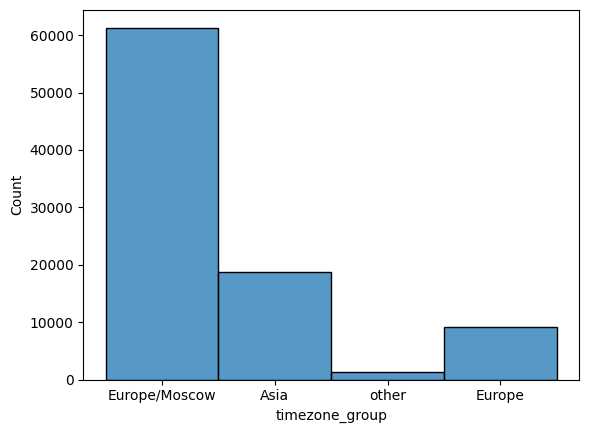

In [ ]:
def timezone_marge(tz):
    if tz is None:
        return "other"
    tz = str(tz)
    if tz == "Europe/Moscow" or tz is None:
        return tz
    elif tz.lower().startswith("europe/"):
        return "Europe"
    elif tz.lower().startswith("asia/"):
        return "Asia"
    else:
        return "other"


df_users["timezone_group"] = df_users["timezone"].apply(lambda x: timezone_marge(x))
df_users.drop(columns=["timezone"], inplace=True)
sns.histplot(df_users["timezone_group"])
plt.show()

In [ ]:
display(df_users["sign_in_count"].value_counts())  # кол-во логинов пользователя на LMS
df_users["sign_in_count"] = (
    df_users["sign_in_count"]
    .astype(str)
    .str.replace(r"[^\d]", "", regex=True)
    .astype(int)
)

display(df_users["sign_in_count"].describe())

,count
sign_in_count,
1,6601
2,6348
3,4178
4,3353
5,3073
...,...
260,1
176,1
303,1


,sign_in_count
count,90647.000000
mean,17.669829
std,33.109249
min,0.000000
25%,4.000000
50%,9.000000
75%,19.000000
max,1390.000000


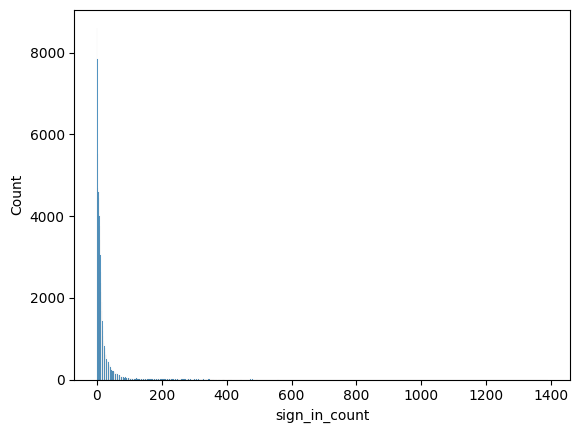

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


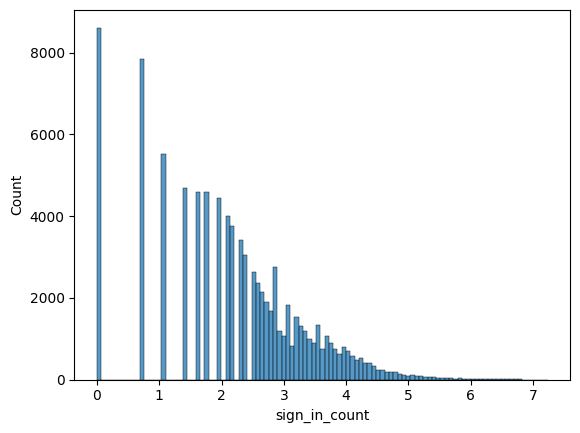

In [ ]:
# Медиана отличается от среднего, значит есть выбросы
# Посмотрим на распределение
sns.histplot(df_users["sign_in_count"])
plt.show()

# Посмотрим на распределение логарифма
sns.histplot(np.log(df_users["sign_in_count"]))
plt.show()

,count
grade_id,
"3,010",0.854579
"3,007",0.040211
"3,006",0.025141
"3,000",0.021159
"3,009",0.019350
"3,008",0.019195
"3,001",0.007667
"3,012",0.004225
"3,005",0.003618


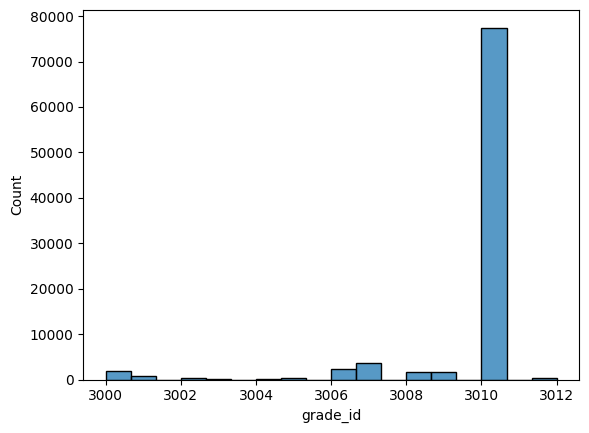

In [ ]:
display(df_users["grade_id"].value_counts() / len(df_users))  # класс пользователя
df_users["grade_id"] = (
    df_users["grade_id"].astype(str).str.replace(r"[^\d]", "", regex=True).astype(int)
)

# Посмотрим на распределение
sns.histplot(df_users["grade_id"])
plt.show()

In [ ]:
# Сильный перекос в сторону класса 3010
# Поле неинформативное, удалим
df_users.drop(columns=["grade_id"], inplace=True)

In [ ]:
df_users.reset_index(drop=True, inplace=True)
df_users.head()

,id,created_at,sign_in_count,with_school,timezone_group
0,675765,2025-04-25 12:57:00,3,1,Europe/Moscow
1,679040,2025-05-22 19:01:00,5,1,Europe/Moscow
2,679200,2025-05-23 09:47:00,3,1,Europe/Moscow
3,678069,2025-05-16 08:38:00,2,1,Europe/Moscow
4,693126,2025-06-19 06:47:00,6,1,Asia


In [ ]:
dataframes["users"] = df_users
del df_users

#### Работа с датасетом users


1. Первичный анализ данных  
- Проведен анализ признаков пользователей: sign_in_count (количество входов), grade_id (класс), is_teacher (признак учителя), subscribed (признак подписки), timezone (часовой пояс), wk_gender (пол), d_wk_school_id/id школы.

2. Обработка и очистка данных  
- Поля sign_in_count и grade_id были приведены к числовому формату с удалением нецифровых символов.
- Выявлены аномалии в распределении sign_in_count (наличие выбросов, медиана отличается от среднего).
- Для анализа распределения sign_in_count построены гистограммы по значениям и их логарифмам.
- Для grade_id выявлен сильный перекос в сторону одного значения (3010), после чего колонка была признана неинформативной и удалена.

3. Итоговое состояние датасета  
- После первичной обработки и удаления неинформативных/проблемных столбцов в финальном датасете остались только следующие поля:
    - id: идентификатор пользователя
    - created_at: временная метка создания аккаунта
    - sign_in_count: количество входов пользователя на платформу
    - with_school: индикатор, привязан ли пользователь к школе
    - timezone_group: сгруппированный часовой пояс
- Были удалены следующие поля:
    - updated_at (удалено)
    - grade_id (низкая информативность, удалено)
    - is_teacher (нет в финальном датасете на данном этапе)
    - subscribed (нет в финальном датасете на данном этапе)
    - d_wk_school_id (удалено)
    - wk_gender (удалено)

Краткие выводы:
- В финальном датасете users для дальнейшего анализа оставлены только те поля, которые гарантированно имеются у всех пользователей и не содержат большого числа пропусков, а также наиболее удобны для последующей обработки.
- Колонки grade_id, is_teacher, subscribed, wk_gender, d_wk_school_id были удалены как неинформативные или с большим количеством пропусков/перекосом в распределении.
- Данные users приведены к компактному и очищенному виду — только ключевая идентификация, осн. временные признаки и минимальная база для feature engineering.

### users_courses


In [ ]:
users_courses = dataframes["users_courses"].copy()

users_courses_raw = users_courses.copy()

print("Исходная форма:", users_courses_raw.shape)

# технический мусор
cols_to_drop = [col for col in ["Unnamed: 0"] if col in users_courses_raw.columns]
users_courses_stage1 = users_courses_raw.drop(columns=cols_to_drop).copy()

# ID-поля -> numeric
id_cols = ["id", "user_id", "course_id", "group_template_id"]
for col in id_cols:
    if col in users_courses_stage1.columns:
        users_courses_stage1[col] = (
            users_courses_stage1[col]
            .astype(str)
            .str.replace(",", "", regex=False)
            .str.strip()
            .replace({"nan": pd.NA, "None": pd.NA, "": pd.NA})
        )
        users_courses_stage1[col] = pd.to_numeric(
            users_courses_stage1[col], errors="coerce"
        )

# Timestamp-поля дата + время
timestamp_cols = ["created_at", "updated_at", "wk_course_completed_at"]

for col in timestamp_cols:
    if col in users_courses_stage1.columns:
        users_courses_stage1[col] = pd.to_datetime(
            users_courses_stage1[col], errors="coerce"
        )

# Date-поля: календарная дата
date_cols = ["access_finished_at", "wk_officially_started_at"]

for col in date_cols:
    if col in users_courses_stage1.columns:
        users_courses_stage1[col] = pd.to_datetime(
            users_courses_stage1[col], errors="coerce"
        )

# Числовые поля
numeric_cols = [
    "wk_points",
    "wk_max_points",
    "wk_max_viewable_lessons",
    "wk_max_task_count",
]

for col in numeric_cols:
    if col in users_courses_stage1.columns:
        users_courses_stage1[col] = (
            users_courses_stage1[col]
            .astype(str)
            .str.replace(",", "", regex=False)
            .str.strip()
            .replace({"nan": pd.NA, "None": pd.NA, "": pd.NA})
        )
        users_courses_stage1[col] = pd.to_numeric(
            users_courses_stage1[col], errors="coerce"
        )

# Удаляем полные дубли
n_before = len(users_courses_stage1)
users_courses_stage1 = users_courses_stage1.drop_duplicates().copy()
n_after = len(users_courses_stage1)

print("После stage1:", users_courses_stage1.shape)
print("Удалено полных дублей:", n_before - n_after)

print("\nТипы после приведения:")
display(users_courses_stage1.dtypes.to_frame("dtype"))

print("\nПроверка: есть ли ненулевое время в date-полях")
date_time_check = {}
for col in date_cols:
    if col in users_courses_stage1.columns:
        non_midnight = (
            users_courses_stage1[col]
            .dropna()
            .dt.time.ne(pd.Timestamp("00:00:00").time())
            .sum()
        )
        date_time_check[col] = non_midnight

display(
    pd.DataFrame.from_dict(
        date_time_check, orient="index", columns=["n_non_midnight_values"]
    )
)

print("\nПропуски после приведения типов:")
display(
    users_courses_stage1.isna()
    .sum()
    .to_frame("null_count")
    .assign(
        null_pct=lambda df: (df["null_count"] / len(users_courses_stage1) * 100).round(
            4
        )
    )
    .sort_values("null_count", ascending=False)
)

Исходная форма: (290835, 13)
После stage1: (290835, 13)
Удалено полных дублей: 0

Типы после приведения:


,dtype
id,int64
user_id,int64
course_id,int64
state,object
created_at,datetime64[ns]
updated_at,datetime64[ns]
access_finished_at,datetime64[ns]
wk_points,float64
wk_max_points,float64
wk_max_viewable_lessons,float64



Проверка: есть ли ненулевое время в date-полях


,n_non_midnight_values
access_finished_at,0
wk_officially_started_at,0



Пропуски после приведения типов:


,null_count,null_pct
wk_course_completed_at,290481,99.8783
wk_officially_started_at,193970,66.6942
wk_points,84910,29.1952
wk_max_points,125,0.0430
wk_max_task_count,125,0.0430
wk_max_viewable_lessons,125,0.0430
access_finished_at,94,0.0323
created_at,0,0.0000
user_id,0,0.0000
id,0,0.0000


In [ ]:
# КЛЮЧИ И БАЗОВАЯ СЕМАНТИЧЕСКАЯ ЧИСТОТА

uc2 = users_courses_stage1.copy()

print("Форма таблицы:", uc2.shape)

# Уникальность id
id_check = pd.DataFrame(
    [
        {
            "n_rows": len(uc2),
            "id_nunique": uc2["id"].nunique(dropna=True),
            "id_is_unique": uc2["id"].is_unique,
        }
    ]
)
display(id_check)

# Уникальность пары (user_id, course_id)
pair_nunique = uc2[["user_id", "course_id"]].drop_duplicates().shape[0]
pair_check = pd.DataFrame(
    [
        {
            "n_rows": len(uc2),
            "pair_nunique": pair_nunique,
            "pair_is_unique": pair_nunique == len(uc2),
        }
    ]
)
display(pair_check)

pair_dups = uc2[
    uc2.duplicated(subset=["user_id", "course_id"], keep=False)
].sort_values(["user_id", "course_id", "created_at"])

print("Число строк в нарушениях пары (user_id, course_id):", len(pair_dups))
display(pair_dups.head(20))

# Проверка state
state_check = uc2["state"].value_counts(dropna=False).to_frame("count")
display(state_check)

# Проверка id <-> (user_id, course_id)
id_to_pair = (
    uc2.groupby("id")
    .agg(n_user_id=("user_id", "nunique"), n_course_id=("course_id", "nunique"))
    .reset_index()
)

print("Есть ли id, соответствующие более чем одному user_id или course_id:")
display(
    id_to_pair[(id_to_pair["n_user_id"] > 1) | (id_to_pair["n_course_id"] > 1)].head(20)
)

Форма таблицы: (290835, 13)


,n_rows,id_nunique,id_is_unique
0,290835,290835,True


,n_rows,pair_nunique,pair_is_unique
0,290835,290835,True


Число строк в нарушениях пары (user_id, course_id): 0


,id,user_id,course_id,state,created_at,updated_at,access_finished_at,wk_points,wk_max_points,wk_max_viewable_lessons,wk_max_task_count,wk_officially_started_at,wk_course_completed_at


,count
state,
active,287548
inactive,3287


Есть ли id, соответствующие более чем одному user_id или course_id:


,id,n_user_id,n_course_id


In [ ]:
# удалим лишний id (зачем его вообще впихнули)
users_courses_stage2 = users_courses_stage1.drop(columns=["id"]).copy()

print("Форма после удаления id:", users_courses_stage2.shape)

print("Проверка уникальности пары (user_id, course_id) после удаления id:")
pair_nunique_after = (
    users_courses_stage2[["user_id", "course_id"]].drop_duplicates().shape[0]
)
print("n_rows =", len(users_courses_stage2))
print("pair_nunique =", pair_nunique_after)
print("pair_is_unique =", pair_nunique_after == len(users_courses_stage2))

display(users_courses_stage2.head())

Форма после удаления id: (290835, 12)
Проверка уникальности пары (user_id, course_id) после удаления id:
n_rows = 290835
pair_nunique = 290835
pair_is_unique = True


,user_id,course_id,state,created_at,updated_at,access_finished_at,wk_points,wk_max_points,wk_max_viewable_lessons,wk_max_task_count,wk_officially_started_at,wk_course_completed_at
0,718902,771,active,2025-10-14 14:55:00,2025-11-10 14:05:00,2026-04-14,45.10,63.0,14.0,63.0,NaT,NaT
1,708314,763,active,2025-09-19 18:04:00,2025-10-02 15:12:00,2026-03-19,2.33,4.0,5.0,4.0,2025-09-19,NaT
2,668960,170000688,active,2025-03-18 08:44:00,2025-04-02 13:14:00,2025-06-30,0.00,66.0,29.0,64.0,NaT,NaT
3,668984,170000688,inactive,2025-03-18 09:26:00,2025-04-02 13:14:00,2025-03-23,0.00,66.0,29.0,64.0,NaT,NaT
4,703125,770,active,2025-09-10 18:35:00,2025-10-06 09:26:00,2026-03-10,0.00,62.0,14.0,62.0,2025-09-10,NaT


In [ ]:
# СЕМАНТИЧЕСКАЯ ДИАГНОСТИКА users_courses


uc3 = users_courses_stage2.copy()

semantic_checks = pd.DataFrame(
    [
        {
            # базовая хронология
            "updated_before_created": (uc3["updated_at"] < uc3["created_at"]).sum(),
            # отдельно по смыслу статуса
            "inactive_access_finished_after_created": (
                (uc3["state"] == "inactive")
                & uc3["access_finished_at"].notna()
                & (uc3["access_finished_at"] > uc3["created_at"])
            ).sum(),
            "active_access_finished_before_created": (
                (uc3["state"] == "active")
                & uc3["access_finished_at"].notna()
                & (uc3["access_finished_at"] < uc3["created_at"])
            ).sum(),
            # учебная логика
            "completed_before_created": (
                uc3["wk_course_completed_at"].notna()
                & (uc3["wk_course_completed_at"] < uc3["created_at"])
            ).sum(),
            "completed_before_start": (
                uc3["wk_course_completed_at"].notna()
                & uc3["wk_officially_started_at"].notna()
                & (uc3["wk_course_completed_at"] < uc3["wk_officially_started_at"])
            ).sum(),
            "start_before_created": (
                uc3["wk_officially_started_at"].notna()
                & (uc3["wk_officially_started_at"] < uc3["created_at"])
            ).sum(),
            # баллы
            "points_gt_max_points": (
                uc3["wk_points"].notna()
                & uc3["wk_max_points"].notna()
                & (uc3["wk_points"] > uc3["wk_max_points"])
            ).sum(),
            "max_points_zero_but_points_positive": (
                uc3["wk_max_points"].fillna(0).eq(0) & uc3["wk_points"].fillna(0).gt(0)
            ).sum(),
            # completion vs state
            "inactive_but_completed": (
                (uc3["state"] == "inactive") & uc3["wk_course_completed_at"].notna()
            ).sum(),
            "active_but_completed": (
                (uc3["state"] == "active") & uc3["wk_course_completed_at"].notna()
            ).sum(),
        }
    ]
)

display(semantic_checks.T.rename(columns={0: "count"}))

# Покажем примеры по главным подозрительным сценариям
checks_examples = {
    "active_access_finished_before_created": (
        (uc3["state"] == "active")
        & uc3["access_finished_at"].notna()
        & (uc3["access_finished_at"] < uc3["created_at"])
    ),
    "completed_before_created": (
        uc3["wk_course_completed_at"].notna()
        & (uc3["wk_course_completed_at"] < uc3["created_at"])
    ),
    "completed_before_start": (
        uc3["wk_course_completed_at"].notna()
        & uc3["wk_officially_started_at"].notna()
        & (uc3["wk_course_completed_at"] < uc3["wk_officially_started_at"])
    ),
    "points_gt_max_points": (
        uc3["wk_points"].notna()
        & uc3["wk_max_points"].notna()
        & (uc3["wk_points"] > uc3["wk_max_points"])
    ),
    "max_points_zero_but_points_positive": (
        uc3["wk_max_points"].fillna(0).eq(0) & uc3["wk_points"].fillna(0).gt(0)
    ),
    "inactive_but_completed": (
        (uc3["state"] == "inactive") & uc3["wk_course_completed_at"].notna()
    ),
}

for name, mask in checks_examples.items():
    print(f"\n=== {name} ===")
    print("count =", mask.sum())
    display(uc3.loc[mask].head(20))

,count
updated_before_created,0
inactive_access_finished_after_created,1709
active_access_finished_before_created,292
completed_before_created,0
completed_before_start,0
start_before_created,96257
points_gt_max_points,179
max_points_zero_but_points_positive,179
inactive_but_completed,0
active_but_completed,354



=== active_access_finished_before_created ===
count = 292


,user_id,course_id,state,created_at,updated_at,access_finished_at,wk_points,wk_max_points,wk_max_viewable_lessons,wk_max_task_count,wk_officially_started_at,wk_course_completed_at
5979,695795,755,active,2025-06-30 03:48:00,2025-06-30 03:48:00,2025-06-30,NaN,5.0,0.0,1.0,NaT,NaT
6466,695795,762,active,2025-06-30 03:48:00,2025-06-30 03:48:00,2025-06-30,NaN,3.0,0.0,1.0,NaT,NaT
6512,695795,769,active,2025-06-30 03:48:00,2025-06-30 03:48:00,2025-06-30,NaN,329.0,32.0,328.0,NaT,NaT
6665,695795,760,active,2025-06-30 03:48:00,2025-06-30 03:48:00,2025-06-30,NaN,109.0,23.0,100.0,NaT,NaT
6860,695795,756,active,2025-06-30 03:48:00,2025-06-30 03:48:00,2025-06-30,NaN,0.0,2.0,0.0,NaT,NaT
7100,695795,170000688,active,2025-06-30 03:48:00,2025-06-30 03:48:00,2025-06-30,NaN,17.0,9.0,16.0,NaT,NaT
13601,695799,769,active,2025-06-30 03:55:00,2025-06-30 03:55:00,2025-06-30,NaN,329.0,32.0,328.0,NaT,NaT
14044,695799,170000688,active,2025-06-30 03:55:00,2025-06-30 03:55:00,2025-06-30,NaN,17.0,9.0,16.0,NaT,NaT
14163,695799,762,active,2025-06-30 03:55:00,2025-06-30 03:55:00,2025-06-30,NaN,3.0,0.0,1.0,NaT,NaT
14255,695799,756,active,2025-06-30 03:55:00,2025-06-30 03:55:00,2025-06-30,NaN,0.0,2.0,0.0,NaT,NaT



=== completed_before_created ===
count = 0


,user_id,course_id,state,created_at,updated_at,access_finished_at,wk_points,wk_max_points,wk_max_viewable_lessons,wk_max_task_count,wk_officially_started_at,wk_course_completed_at


...

,user_id,course_id,state,created_at,updated_at,access_finished_at,wk_points,wk_max_points,wk_max_viewable_lessons,wk_max_task_count,wk_officially_started_at,wk_course_completed_at
733,670793,762,active,2025-03-28 00:44:00,2025-04-08 02:56:00,2025-06-30,1.00,0.0,0.0,0.0,NaT,NaT
1723,665783,755,active,2025-02-18 16:44:00,2025-03-25 06:30:00,2025-06-30,1.00,0.0,0.0,0.0,NaT,NaT
1752,671026,762,active,2025-03-28 00:44:00,2025-04-14 05:21:00,2025-06-30,1.00,0.0,0.0,0.0,NaT,NaT
3098,679051,762,active,2025-05-22 23:47:00,2025-05-22 23:54:00,2025-06-30,2.00,0.0,0.0,1.0,NaT,NaT
3732,669327,762,active,2025-03-28 00:43:00,2025-04-15 18:57:00,2025-06-30,2.00,0.0,0.0,0.0,NaT,NaT
4209,665823,762,active,2025-03-28 00:39:00,2025-04-17 09:24:00,2025-06-30,2.00,0.0,0.0,0.0,NaT,NaT
4560,668106,762,active,2025-03-28 00:41:00,2025-04-02 09:54:00,2025-06-30,2.00,0.0,0.0,0.0,NaT,NaT
5118,669815,170000688,active,2025-03-21 07:38:00,2025-03-21 07:51:00,2025-06-30,1.75,0.0,0.0,64.0,NaT,NaT
5532,671484,762,active,2025-03-28 18:15:00,2025-04-04 11:26:00,2025-06-30,1.00,0.0,0.0,0.0,NaT,NaT
7156,671523,762,active,2025-03-30 10:31:00,2025-04-02 14:02:00,2025-06-30,1.00,0.0,0.0,0.0,NaT,NaT



=== max_points_zero_but_points_positive ===
count = 179


,user_id,course_id,state,created_at,updated_at,access_finished_at,wk_points,wk_max_points,wk_max_viewable_lessons,wk_max_task_count,wk_officially_started_at,wk_course_completed_at
733,670793,762,active,2025-03-28 00:44:00,2025-04-08 02:56:00,2025-06-30,1.00,0.0,0.0,0.0,NaT,NaT
1723,665783,755,active,2025-02-18 16:44:00,2025-03-25 06:30:00,2025-06-30,1.00,0.0,0.0,0.0,NaT,NaT
1752,671026,762,active,2025-03-28 00:44:00,2025-04-14 05:21:00,2025-06-30,1.00,0.0,0.0,0.0,NaT,NaT
3098,679051,762,active,2025-05-22 23:47:00,2025-05-22 23:54:00,2025-06-30,2.00,0.0,0.0,1.0,NaT,NaT
3732,669327,762,active,2025-03-28 00:43:00,2025-04-15 18:57:00,2025-06-30,2.00,0.0,0.0,0.0,NaT,NaT
4209,665823,762,active,2025-03-28 00:39:00,2025-04-17 09:24:00,2025-06-30,2.00,0.0,0.0,0.0,NaT,NaT
4560,668106,762,active,2025-03-28 00:41:00,2025-04-02 09:54:00,2025-06-30,2.00,0.0,0.0,0.0,NaT,NaT
5118,669815,170000688,active,2025-03-21 07:38:00,2025-03-21 07:51:00,2025-06-30,1.75,0.0,0.0,64.0,NaT,NaT
5532,671484,762,active,2025-03-28 18:15:00,2025-04-04 11:26:00,2025-06-30,1.00,0.0,0.0,0.0,NaT,NaT
7156,671523,762,active,2025-03-30 10:31:00,2025-04-02 14:02:00,2025-06-30,1.00,0.0,0.0,0.0,NaT,NaT



=== inactive_but_completed ===
count = 0


,user_id,course_id,state,created_at,updated_at,access_finished_at,wk_points,wk_max_points,wk_max_viewable_lessons,wk_max_task_count,wk_officially_started_at,wk_course_completed_at


In [ ]:
# ЖЕСТКОЕ ПРАВИЛО ОЧИСТКИ ПО access_finished_at

uc4 = users_courses_stage2.copy()

uc4["created_date"] = uc4["created_at"].dt.normalize()
uc4["access_finished_date"] = uc4["access_finished_at"].dt.normalize()

# created_date - access_finished_date
uc4["created_minus_access_finished_days"] = (
    uc4["created_date"] - uc4["access_finished_date"]
).dt.days

# только для active, где access_finished_at раньше created_at по дате
mask_active_finished_before = (
    (uc4["state"] == "active")
    & uc4["access_finished_date"].notna()
    & (uc4["access_finished_date"] < uc4["created_date"])
)

active_finished_before = uc4.loc[mask_active_finished_before].copy()

print("Число active-строк, где access_finished_at_date < created_date:")
print(len(active_finished_before))

print("\nРаспределение по разнице в днях:")
display(
    active_finished_before["created_minus_access_finished_days"]
    .value_counts(dropna=False)
    .sort_index()
    .to_frame("count")
)

# допустимо: разница 1 день
uc4["flag_access_finished_before_created_1day"] = (
    (uc4["state"] == "active") & uc4["created_minus_access_finished_days"].eq(1)
).astype(int)

# аномалия: разница больше 1 дня
uc4["flag_access_finished_before_created_gt_1day"] = (
    (uc4["state"] == "active") & uc4["created_minus_access_finished_days"].gt(1)
).astype(int)

# прочие диагностические флаги
uc4["flag_inactive"] = (uc4["state"] == "inactive").astype(int)

uc4["flag_zero_max_points_with_positive_points"] = (
    uc4["wk_max_points"].fillna(0).eq(0) & uc4["wk_points"].fillna(0).gt(0)
).astype(int)

flag_summary = pd.DataFrame(
    {
        "flag": [
            "flag_access_finished_before_created_1day",
            "flag_access_finished_before_created_gt_1day",
            "flag_inactive",
            "flag_zero_max_points_with_positive_points",
        ],
        "count": [
            uc4["flag_access_finished_before_created_1day"].sum(),
            uc4["flag_access_finished_before_created_gt_1day"].sum(),
            uc4["flag_inactive"].sum(),
            uc4["flag_zero_max_points_with_positive_points"].sum(),
        ],
    }
)

display(flag_summary)

print("\nПримеры строк с разницей > 1 дня:")
display(
    uc4.loc[
        uc4["flag_access_finished_before_created_gt_1day"] == 1,
        [
            "user_id",
            "course_id",
            "state",
            "created_at",
            "access_finished_at",
            "created_minus_access_finished_days",
            "wk_points",
            "wk_max_points",
            "wk_officially_started_at",
            "wk_course_completed_at",
        ],
    ].head(30)
)

Число active-строк, где access_finished_at_date < created_date:
0

Распределение по разнице в днях:


,count
created_minus_access_finished_days,


,flag,count
0,flag_access_finished_before_created_1day,0
1,flag_access_finished_before_created_gt_1day,0
2,flag_inactive,3287
3,flag_zero_max_points_with_positive_points,179



Примеры строк с разницей > 1 дня:


,user_id,course_id,state,created_at,access_finished_at,created_minus_access_finished_days,wk_points,wk_max_points,wk_officially_started_at,wk_course_completed_at


In [ ]:
# final clean
users_courses = uc4.drop(
    columns=[
        "created_date",
        "access_finished_date",
        "created_minus_access_finished_days",
        "flag_access_finished_before_created_1day",
        "flag_access_finished_before_created_gt_1day",
    ],
    errors="ignore",
).copy()

print("Форма users_courses:", users_courses.shape)

print("\nПроверка уникальности пары (user_id, course_id):")
pair_nunique = users_courses[["user_id", "course_id"]].drop_duplicates().shape[0]
print("n_rows =", len(users_courses))
print("pair_nunique =", pair_nunique)
print("pair_is_unique =", pair_nunique == len(users_courses))

print("\nСводка по финальным флагам:")
display(
    pd.DataFrame(
        {
            "flag": ["flag_inactive", "flag_zero_max_points_with_positive_points"],
            "count": [
                users_courses["flag_inactive"].sum(),
                users_courses["flag_zero_max_points_with_positive_points"].sum(),
            ],
        }
    )
)

display(users_courses.head())

Форма users_courses: (290835, 14)

Проверка уникальности пары (user_id, course_id):
n_rows = 290835
pair_nunique = 290835
pair_is_unique = True

Сводка по финальным флагам:


,flag,count
0,flag_inactive,3287
1,flag_zero_max_points_with_positive_points,179


,user_id,course_id,state,created_at,updated_at,access_finished_at,wk_points,wk_max_points,wk_max_viewable_lessons,wk_max_task_count,wk_officially_started_at,wk_course_completed_at,flag_inactive,flag_zero_max_points_with_positive_points
0,718902,771,active,2025-10-14 14:55:00,2025-11-10 14:05:00,2026-04-14,45.10,63.0,14.0,63.0,NaT,NaT,0,0
1,708314,763,active,2025-09-19 18:04:00,2025-10-02 15:12:00,2026-03-19,2.33,4.0,5.0,4.0,2025-09-19,NaT,0,0
2,668960,170000688,active,2025-03-18 08:44:00,2025-04-02 13:14:00,2025-06-30,0.00,66.0,29.0,64.0,NaT,NaT,0,0
3,668984,170000688,inactive,2025-03-18 09:26:00,2025-04-02 13:14:00,2025-03-23,0.00,66.0,29.0,64.0,NaT,NaT,1,0
4,703125,770,active,2025-09-10 18:35:00,2025-10-06 09:26:00,2026-03-10,0.00,62.0,14.0,62.0,2025-09-10,NaT,0,0


In [ ]:
users_courses = users_courses.copy()
dataframes["users_courses"] = users_courses

try:
    del users_courses
    del users_courses
except:
    pass

#### details `users_courses`

На этапе предобработки были выполнены следующие действия:

1. Удален технический столбец `Unnamed: 0`.
2. Удален столбец `id` как избыточный, поскольку:
   - `id` уникален,
   - пара `(user_id, course_id)` также уникальна,
   - следовательно, аналитическая сущность строки полностью определяется парой `(user_id, course_id)`.
3. Приведены типы:
   - идентификаторы — к числовому типу,
   - `created_at`, `updated_at`, `wk_course_completed_at` — к timestamp,
   - `access_finished_at`, `wk_officially_started_at` — к date-like datetime,
   - числовые учебные поля — к `float`.
4. Проверены полные дубликаты: полных дублей не обнаружено.
5. Проверена временная консистентность:
   - случаев `updated_at < created_at` не найдено;
   - случаев `wk_course_completed_at < created_at` не найдено;
   - случаев `wk_course_completed_at < wk_officially_started_at` не найдено;
   - после корректного сравнения по календарной дате не найдено ни одного случая, где для `state = active` дата `access_finished_at` была бы раньше даты `created_at`.
6. По результатам ответов заказчика строки со следующими сценариями не удалялись:
   - `wk_officially_started_at < created_at`,
   - `state = inactive`,
   - `state = active` и заполненный `wk_course_completed_at`.

Итог: из таблицы не удалялась ни одна строка по содержательным причинам.  
Финальная clean-версия строится как структурно очищенная таблица с двумя диагностическими флагами:
- `flag_inactive`,
- `flag_zero_max_points_with_positive_points`.

### wk_media_view_sessions
Данные по сессиям просмотров медиа-контента внутри LMS



In [ ]:
df_wk_media_view_sessions = dataframes["wk_media_view_sessions"].copy()
df_wk_media_view_sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 852358 entries, 0 to 852357
Data columns (total 7 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   resource_type          852358 non-null  object
 1   resource_id            852358 non-null  object
 2   viewer_id              852358 non-null  object
 3   segments_total         852358 non-null  int64 
 4   viewed_segments_count  852358 non-null  int64 
 5   started_at             852358 non-null  object
 6   kind                   852358 non-null  object
dtypes: int64(2), object(5)
memory usage: 45.5+ MB


In [ ]:
# viewer_id == user_id
df_wk_media_view_sessions.rename(columns={"viewer_id": "user_id"}, inplace=True)

In [ ]:
# Приведение типов
df_wk_media_view_sessions["user_id"] = pd.to_numeric(
    df_wk_media_view_sessions["user_id"].astype(str).str.replace(r"\D", "", regex=True)
).astype("Int64")
df_wk_media_view_sessions["resource_id"] = pd.to_numeric(
    df_wk_media_view_sessions["resource_id"]
    .astype(str)
    .str.replace(r"\D", "", regex=True)
).astype("Int64")

df_wk_media_view_sessions["started_at"] = pd.to_datetime(
    df_wk_media_view_sessions["started_at"]
)
df_wk_media_view_sessions.describe()

,resource_id,user_id,segments_total,viewed_segments_count,started_at
count,852358.0,852358.0,852358.000000,852358.000000,852358
mean,189821.057703,722081.52668,18.296854,11.939380,2025-11-24 09:50:05.723439872
min,5658.0,665744.0,1.000000,1.000000,2025-03-28 05:58:00
25%,5951.0,704571.0,8.000000,2.000000,2025-11-01 12:35:00
50%,6014.0,720112.0,10.000000,8.000000,2025-11-30 17:59:00
75%,10492.75,741622.0,37.000000,11.000000,2025-12-12 05:27:00
max,170005372.0,761599.0,190.000000,186.000000,2026-03-27 14:08:00
std,4415447.385057,22483.214357,17.155832,13.878893,NaN


In [ ]:
# 852358 записей, пропусков нет
print(f"Дубликатов: {df_wk_media_view_sessions.duplicated().sum()}")

df_wk_media_view_sessions.drop_duplicates(inplace=True)

df_wk_media_view_sessions.info()
# 848800 записей, пропусков нет
print(f"Дубликатов: {df_wk_media_view_sessions.duplicated().sum()}")

Дубликатов: 3558
<class 'pandas.core.frame.DataFrame'>
Index: 848800 entries, 0 to 852357
Data columns (total 7 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   resource_type          848800 non-null  object        
 1   resource_id            848800 non-null  Int64         
 2   user_id                848800 non-null  Int64         
 3   segments_total         848800 non-null  int64         
 4   viewed_segments_count  848800 non-null  int64         
 5   started_at             848800 non-null  datetime64[ns]
 6   kind                   848800 non-null  object        
dtypes: Int64(2), datetime64[ns](1), int64(2), object(2)
memory usage: 53.4+ MB
Дубликатов: 0


In [ ]:
print("Соотношение типов ресурсов:")
display(
    df_wk_media_view_sessions["resource_type"].value_counts()
    / len(df_wk_media_view_sessions)
)

# id активности, в рамках которой было взаимодействие с задачей
# Не удаляю, вдруг пригодиться для связи с user_answers
print("Соотношение resource_id:")
display(df_wk_media_view_sessions["resource_id"].unique())

# удаляем строки, user_id которых отсутствует в датафрейме dataframes['users']
df_wk_media_view_sessions = df_wk_media_view_sessions[
    df_wk_media_view_sessions["user_id"].isin(dataframes["users"]["id"])
]

# segments_total и viewed_segments_count объединяем в один признак - глубина просмотра viewed_segments_count/segments_total
df_wk_media_view_sessions["viewed_segments_count"] = df_wk_media_view_sessions[
    "viewed_segments_count"
].astype(float)
df_wk_media_view_sessions["segments_total"] = df_wk_media_view_sessions[
    "segments_total"
].astype(float)

df_wk_media_view_sessions["depth"] = (
    df_wk_media_view_sessions["viewed_segments_count"]
    / df_wk_media_view_sessions["segments_total"]
)

# удаляем лишние колонки
df_wk_media_view_sessions.drop(
    columns=["viewed_segments_count", "segments_total"], inplace=True
)

Соотношение типов ресурсов:


,count
resource_type,
Lesson,0.726848
Group,0.273152


Соотношение resource_id:


<IntegerArray>
[ 5837,  5834,  5859,  5839,  5848,  5838,  5840,  5841,  5852,  5843,
 ...
 18905, 18906, 19323, 15029, 19036, 19324, 16188, 19175, 18907,  8490]
Length: 6298, dtype: Int64

In [ ]:
df_wk_media_view_sessions["kind"].value_counts()

,count
kind,
kinescope,610085
ulms_vod,165593
ulms_live,53860


In [ ]:
df_wk_media_view_sessions.reset_index(drop=True, inplace=True)
print(
    f'уникальность по user_id: {df_wk_media_view_sessions.shape[0] == df_wk_media_view_sessions["user_id"].nunique()}'
)
df_wk_media_view_sessions.dtypes

уникальность по user_id: False


,0
resource_type,object
resource_id,Int64
user_id,Int64
started_at,datetime64[ns]
kind,object
depth,float64


In [ ]:
# группировка по user_id
df_wk_media_view_sessions = (
    df_wk_media_view_sessions.groupby(["user_id"])
    .agg(
        {
            "user_id": "first",
            "depth": "mean",
            "resource_id": "value_counts",
            "resource_type": "value_counts",
            "started_at": "min",
            "started_at": "max",
            "kind": "value_counts",
        }
    )
    .reset_index()
)

In [ ]:
dataframes["wk_media_view_sessions_agg"] = df_wk_media_view_sessions
del df_wk_media_view_sessions

#### Работа с датасетом wk_media_view_sessions


1. Были обнаружены и удалены дубликаты — в датасете осталось 848800 уникальных записей.

2. Строки с user_id, которых не было в датафрейме пользователей (`df_users`), были удалены для согласованности данных.

3. Был объединён признак глубины просмотра видео: из полей `segments_total` и `viewed_segments_count` рассчитано новое поле `depth` как их отношение (`viewed_segments_count`/`segments_total`).

4. После расчёта глубины просмотра были удалены признаки `segments_total` и `viewed_segments_count` как неактуальные.

5. Произведена очистка индексов и базовая инфо-диагностика по датасету.

В итоге датасет содержит только уникальные, согласованные с пользователями записи, а также необходимый набор признаков для дальнейшего анализа за счёт удаления лишних и создания информативного поля глубины просмотра.

### wk_users_courses_actions

### Создание маски по заданному проценту прохождения курсов

In [ ]:
# Temp: Перезагрузка users_courses
csv_path = DATA_DIR / "users_courses.csv"
dataframes['users_courses'] = pd.read_csv(csv_path)
users_courses = dataframes['users_courses']
print(f"users_courses перезагружен. Размер: {users_courses.shape}")
print(f"Столбцы: {users_courses.columns.tolist()}")

users_courses перезагружен. Размер: (290835, 14)
Столбцы: ['Unnamed: 0', 'id', 'user_id', 'course_id', 'state', 'created_at', 'updated_at', 'access_finished_at', 'wk_points', 'wk_max_points', 'wk_max_viewable_lessons', 'wk_max_task_count', 'wk_officially_started_at', 'wk_course_completed_at']


/tmp/ipykernel_10388/2630903082.py:3: DtypeWarning: Columns (9,11) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframes['users_courses'] = pd.read_csv(csv_path)


#### Определение фукнций

In [ ]:
def clean_id(series):
    """Убирает запятые-разделители тысяч из ID полей"""
    return series.astype(str).str.replace(',', '')

In [ ]:
def build_lesson_mask(user_lessons_df, users_courses_df, lessons_df, cutoff_pct=0.5):
    """
    Строит маску первых N% уроков для каждого user_id & course_id (Ранжирование по lesson_in, порядок создания уроков).

    Returns: DataFrame с колонками [user_id, course_id, lesson_id]
    """
    # Подготовка user_lessons
    ul = user_lessons_df.copy()
    ul['users_course_id_clean'] = clean_id(ul['users_course_id'])
    ul['lesson_id_clean'] = clean_id(ul['lesson_id'])
    ul['lesson_id_num'] = pd.to_numeric(ul['lesson_id_clean'], errors='coerce')

    # Маппинг users_course_id для связки user_id & course_id
    uc = users_courses_df.copy()
    uc['uc_id_clean'] = clean_id(uc['id'])
    uc['user_id_clean'] = clean_id(uc['user_id'])
    uc['course_id_clean'] = clean_id(uc['course_id'])
    uc['access_finished_dt'] = pd.to_datetime(uc['access_finished_at'], format='mixed', dayfirst=True, errors='coerce')
    uc['course_ended'] = uc['access_finished_dt'] < pd.Timestamp.now()

    # Только завершённые курсы с активностью
    uc = uc[(uc['course_ended']) & (uc['wk_points'].notna()) & (uc['wk_points'] > 0)]
    uc_map = uc[['uc_id_clean', 'user_id_clean', 'course_id_clean']]

    # Джойн для добавления связки user_id & course_id
    ul_mapped = ul.merge(uc_map, left_on='users_course_id_clean', right_on='uc_id_clean', how='inner')

    # Ранжирование по lesson_id внутри user_id & course_id
    ul_mapped['lesson_rank'] = ul_mapped.groupby(
        ['user_id_clean', 'course_id_clean']
    )['lesson_id_num'].rank(method='dense')

    ul_mapped['total_lessons'] = ul_mapped.groupby(
        ['user_id_clean', 'course_id_clean']
    )['lesson_id_num'].transform('nunique')

    ul_mapped['lesson_pct'] = ul_mapped['lesson_rank'] / ul_mapped['total_lessons']

    # Маска: первые N%
    mask = ul_mapped[ul_mapped['lesson_pct'] <= cutoff_pct][
        ['user_id_clean', 'course_id_clean', 'lesson_id_clean']
    ].drop_duplicates()

    # Переименование
    mask = mask.rename(columns = {'user_id_clean': 'user_id',
                                  'course_id_clean': 'course_id',
                                  'lesson_id_clean': 'lesson_id'})

    return mask

In [ ]:
def build_time_mask(user_lessons_df, users_courses_df, user_activity_histories_df, cutoff_pct=0.5):
    """
    Строит маску первых N% по времени для каждого user_id & course_id (Ранжирование по времени активности).

    Returns: DataFrame с колонками [user_id, course_id, lesson_id]
    """
    # Подготовка user_lessons
    ul = user_lessons_df.copy()
    ul['ul_id_clean'] = clean_id(ul['id'])
    ul['users_course_id_clean'] = clean_id(ul['users_course_id'])
    ul['lesson_id_clean'] = clean_id(ul['lesson_id'])

    # Маппинг users_course_id для связки user_id & course_id + даты
    uc = users_courses_df.copy()
    uc['uc_id_clean'] = clean_id(uc['id'])
    uc['user_id_clean'] = clean_id(uc['user_id'])
    uc['course_id_clean'] = clean_id(uc['course_id'])
    uc['access_finished_dt'] = pd.to_datetime(uc['access_finished_at'], format='mixed', dayfirst=True, errors='coerce')
    uc['created_dt'] = pd.to_datetime(uc['created_at'], format='mixed', dayfirst=True, errors='coerce')
    uc['course_ended'] = uc['access_finished_dt'] < pd.Timestamp.now()

    # Только завершённые курсы с активностью
    uc_ended = uc[(uc['course_ended']) & (uc['wk_points'].notna()) & (uc['wk_points'] > 0)].copy()
    uc_ended['midpoint'] = uc_ended['created_dt'] + (uc_ended['access_finished_dt'] - uc_ended['created_dt']) * cutoff_pct

    uc_map = uc_ended[['uc_id_clean', 'user_id_clean', 'course_id_clean', 'midpoint']]

    # Джойн для добавления связки user_id & course_id
    ul_mapped = ul.merge(uc_map, left_on='users_course_id_clean', right_on='uc_id_clean', how='inner')

    # Даты активности из user_activity_histories
    uah = user_activity_histories_df.copy()
    uah['user_lesson_id_clean'] = clean_id(uah['user_lesson_id'])
    uah['action_dt'] = pd.to_datetime(uah['created_at'], format='mixed', errors='coerce')

    # Первая дата активности на каждом user_lesson
    first_action = uah.groupby('user_lesson_id_clean')['action_dt'].min().reset_index(name='first_action_dt')

    # Джойн даты к user_lessons
    ul_with_time = ul_mapped.merge(first_action, left_on='ul_id_clean', right_on='user_lesson_id_clean', how='left')

    # Фильтр: только уроки до midpoint
    mask = ul_with_time[ul_with_time['first_action_dt'] <= ul_with_time['midpoint']][
        ['user_id_clean', 'course_id_clean', 'lesson_id_clean']
    ].drop_duplicates()

    # Переименование
    mask = mask.rename(columns = {'user_id_clean': 'user_id',
                                  'course_id_clean': 'course_id',
                                  'lesson_id_clean': 'lesson_id'})

    return mask

In [ ]:
def mask_statistics(mask, users_courses_df, mask_name="Маска"):
    """
    Выводит статистику по маске.
    """
    # Подготовка users_courses
    uc = users_courses_df.copy()
    uc['user_id'] = clean_id(uc['user_id'])
    uc['course_id'] = clean_id(uc['course_id'])
    uc['access_finished_dt'] = pd.to_datetime(uc['access_finished_at'], format='mixed', dayfirst=True, errors='coerce')
    uc['course_ended'] = uc['access_finished_dt'] < pd.Timestamp.now()
    uc_ended = uc[(uc['course_ended']) & (uc['wk_points'].notna()) & (uc['wk_points'] > 0)]

    # Всего уроков в маске в разрезе user_id & course_id
    mask_uc = mask.groupby(['user_id', 'course_id'])['lesson_id'].nunique().reset_index(name='lessons_in_mask')

    # Пересечение с завершёнными курсами
    ended_keys = set(zip(uc_ended['user_id'], uc_ended['course_id']))
    mask_keys = set(zip(mask_uc['user_id'], mask_uc['course_id']))

    print(f"{'#'*60}")
    print(f" {mask_name}")
    print(f"{'#'*60}")
    print(f"\n--- Общая статистика ---")
    print(f"Записей user_id & course_id & lesson_id: {len(mask)}")
    print(f"Уникальных user_id & course_id: {len(mask_uc)}")
    print(f"Уникальных user_id: {mask_uc['user_id'].nunique()}")
    print(f"Уникальных course_id: {mask_uc['course_id'].nunique()}")

    print(f"\n--- Покрытие завершённых курсов ---")
    print(f"Всего завершённых курсов с активностью: {len(ended_keys)}")
    print(f"Покрыто маской: {len(mask_keys & ended_keys)} ({len(mask_keys & ended_keys)/len(ended_keys)*100:.1f}%)")

    print(f"\n--- Уроков в маске в разрезе user_id & course_id ---")
    print(mask_uc['lessons_in_mask'].describe().round(2).to_string())

In [ ]:
# Построение маски по урокам
mask_lessons = build_lesson_mask(dataframes['user_lessons'], dataframes['users_courses'], dataframes['lessons'], cutoff_pct=0.5)

# Построение маски по времени активности
mask_time = build_time_mask(dataframes['user_lessons'], dataframes['users_courses'], dataframes['user_activity_histories'], cutoff_pct=0.5)

print("\n")
mask_statistics(mask_lessons, dataframes['users_courses'], mask_name="Подход 1: 50% уроков (по lesson_id)")
print("\n")
mask_statistics(mask_time, dataframes['users_courses'], mask_name="Подход 2: 50% времени (по дате активности)")



############################################################
 Подход 1: 50% уроков (по lesson_id)
############################################################

--- Общая статистика ---
Записей user_id & course_id & lesson_id: 400165
Уникальных user_id & course_id: 62207
Уникальных user_id: 30396
Уникальных course_id: 32

--- Покрытие завершённых курсов ---
Всего завершённых курсов с активностью: 63454
Покрыто маской: 62207 (98.0%)

--- Уроков в маске в разрезе user_id & course_id ---
count    62207.00
mean         6.43
std          3.19
min          1.00
25%          3.00
50%          8.00
75%          8.00
max         28.00


############################################################
 Подход 2: 50% времени (по дате активности)
############################################################

--- Общая статистика ---
Записей user_id & course_id & lesson_id: 688317
Уникальных user_id & course_id: 60299
Уникальных user_id: 30217
Уникальных course_id: 31

--- Покрытие завершённых курсов -

**Комментарии:**
- Подход 1 берёт строго 50% уроков (в среднем 6.4 урока) и покрывает 98% общего количества записей user_id & course_id (60.4к);
- Подход 2 берет записи по урокам за первую половину срока (время завершения курса - время первой активности по нему) и покрывает 94.9% общего количества записей user_id & course_id (58.5K);
- Подход 2 выделяет примерно в 2 раза больше уроков (в среднем 11.3) - вероятно потому что студенты проходят большую часть материала в первой половине курса. При этом покрывает меньше ключей user_id & course_id из-за дополнительной зависимости от наличия записей в `user_activity_histories`.

**Вывод:**
- Предлагается выбрать подход 1, так как:
    - Выше покрытие данных (по ключу user_id & course_id);
    - Не зависит от внешних таблиц (записей по активности);
    - Нет смещения по темпам прохождения и распределению уроков в рамках курса.

### Мерж очищенных данных по уникальному сочетанию `(user_id, course_id)`

В качестве основной таблицы берем user_courses, к ней по очереди мержим таблицы:
1. users (без группировки, `inner join`)
1. `user_trainings`
1.

In [ ]:
len_uc = dataframes["users_courses"].shape[0]


def user_course_check(dataset):
    """
    Проверка, сохраняется ли уникальность по user_id + course_id
    """
    global len_uc
    print(f"Разница с len(users_courses) = {len_uc - dataset.shape[0]}")
    len_ds = dataset[["user_id", "course_id"]].drop_duplicates().shape[0]
    print(f"len_ds == dataset.shape[0] {len_ds} == {dataset.shape[0]}")
    return len_ds == dataset.shape[0]

#### users_courses

In [ ]:
merged_dataframe = dataframes["users_courses"]
print(f"user_course_check = {user_course_check(merged_dataframe)}")

Разница с len(users_courses) = 0
len_ds == dataset.shape[0] 290835 == 290835
user_course_check = True


#### users

In [ ]:
merged_dataframe = merged_dataframe.merge(
    dataframes["users"],
    left_on="user_id",
    right_on="id",
    suffixes=("_uc", "_u"),
    how="inner",
)
print(f"user_course_check = {user_course_check(merged_dataframe)}")

ValueError: You are trying to merge on object and Int64 columns for key 'user_id'. If you wish to proceed you should use pd.concat

#### user_trainings

In [ ]:
merged_dataframe = merged_dataframe.merge(
    dataframes["ut_features"], on=["user_id", "course_id"], suffixes=("", "_ut")
).reset_index()
print(f"user_course_check = {user_course_check(merged_dataframe)}")

#### wk_media_view_sessions

In [ ]:
merged_dataframe = merged_dataframe.merge(
    dataframes["wk_media_view_sessions_agg"],
    on="user_id",
    suffixes=("", "_wk_media_view_sessions"),
).reset_index()
print(f"user_course_check = {user_course_check(merged_dataframe)}")

In [ ]:
MRGED_DATA_FOLDER_ID = "1pf7F__1ZCMtMGbjkGr1NsLss7vO7zkOk"

# Локально удаляем существующий файл, если он есть
if os.path.exists("merged_dataframe.csv"):
    os.remove("merged_dataframe.csv")

# Сохраняем объединённый датафрейм в новый csv
merged_dataframe.to_csv("merged_dataframe.csv", index=False)

# Авторизация в Google Drive
auth.authenticate_user()

scopes = ["https://www.googleapis.com/auth/drive"]
creds, project = google.auth.default(
    scopes=["https://www.googleapis.com/auth/drive.file"]
)
service = build("drive", "v3", credentials=creds, cache_discovery=False)

# Формируем имя файла с датой и пользователем, выгружаем на диск
user_info_service = build("oauth2", "v2", credentials=creds)
user_info = user_info_service.userinfo().get().execute()
user_email = user_info.get("email", "unknown_user")
safe_user = re.sub(r"\W+", "_", user_email.split("@")[0])

file_name = f"{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}_{safe_user}_merged_dataframe.csv"

file_metadata = {"name": file_name, "parents": [MRGED_DATA_FOLDER_ID]}
media = MediaFileUpload("/content/merged_dataframe.csv", mimetype="text/csv")
file = (
    service.files().create(body=file_metadata, media_body=media, fields="id").execute()
)
print("Uploaded file id:", file["id"], "with name:", file_name)

Uploaded file id: 14t4hvBOpMWw8Vjvfj_IGCaICcrvOGqYS with name: 2026-04-16_20-29-41_chrngvg_merged_dataframe.csv


In [ ]:
merged_dataframe.dtypes

,0
Unnamed: 0,int64
id,int64
user_id,object
course_id,object
state,object
created_at,object
updated_at,object
access_finished_at,object
wk_points,float64
wk_max_points,object


| Поле                                         | Описание                                                                                                                  |
|-----------------------------------------------|---------------------------------------------------------------------------------------------------------------------------|
| level_0, index                               | Индексы после reset_index, могут быть удалены при необходимости                                                           |
| user_id                                      | Уникальный идентификатор пользователя                                                                                     |
| course_id                                    | Уникальный идентификатор курса                                                                                            |
| state                                        | Статус пользователя на курсе (active/inactive)                                                                            |
| created_at_uc                                | Дата первого появления user_id на курсе (или anal. дата регистрации на курсе)                                             |
| updated_at                                   | Дата последнего обновления                                                                                                 |
| access_finished_at                           | Дата окончания доступа                                                                                                     |
| wk_points                                    | Набранные баллы по курсу                                                                                                   |
| wk_max_points                                | Макс. возможные баллы по курсу                                                                                            |
| wk_max_viewable_lessons                      | Количество доступных уроков                                                                                               |
| wk_max_task_count                            | Количество задач в курсе                                                                                                  |
| wk_officially_started_at                     | Дата официального старта курса                                                                                            |
| wk_course_completed_at                       | Дата завершения курса                                                                                                     |
| flag_inactive                                | Флаг неактивности user_id на курсе                                                                                        |
| flag_zero_max_points_with_positive_points     | Флаг: max_points==0, но есть набранные баллы                                                                              |
| sign_in_count                                | Количество логинов пользователя                                                                                           |
| reg_date/created_at_user                     | Дата регистрации пользователя в системе                                                                                   |
| first_activity_date                          | Дата первой активности пользователя (например, earliest created_at или действие в системе)                                |
| grade_id                                     | Группа/класс пользователя (категориальная переменная)                                                                     |
| subscribed                                   | Признак подписки                                                                                                          |
| is_teacher                                   | Признак преподавателя                                                                                                     |
| timezone                                     | Таймзона пользователя                                                                                                     |
| d_wk_school_id                               | Привязка к школе (ID школы, если есть)                                                                                    |
| wk_gender                                    | Пол пользователя (1.0 - мальчик, 2.0 - девочка)                                                                           |
| sessions_count (ut_sessions_count)            | Количество пользовательских сессий                                                                                        |
| session_avg_duration (ut_duration_mean)       | Средняя продолжительность пользовательских сессий                                                                         |
| ut_span_days                                 | Протяжённость активности пользователя, дни                                                                                |
| ut_solved_tasks_mean                         | Среднее число решённых задач                                                                                              |
| ut_solved_tasks_std                          | Стандартное отклонение по решённым задачам                                                                                |
| ut_solved_tasks_median                       | Медианное число решённых задач                                                                                            |
| ut_checked_percent_mean                      | Средний % проверенных задач                                                                                               |
| ut_duration_std                              | Стандартное отклонение продолжительности сессии                                                                           |
| ut_duration_median                           | Медианная продолжительность сессии                                                                                        |
| crit_4_tk_points/mark/checked                | Статистики по критерию 4 (например контрольные работы) — набрано баллов, максимальный балл, отмечены ли задания           |
| crit_5_refl_checked                          | Признак выполнения рефлексии по критерию 5                                                                                |
| crit_6_pa_passed, crit_6_pa_max_points/mark  | Флаги и значения по прохождению (crit_6), баллы                                                                           |
| index_wk_media_view_sessions                 | Индексы сессий просмотра видео                                                                                            |
| views_count_wk_media_view_sessions           | Количество просмотров (wk_media_view_sessions_agg)                                                                        |
| depth                                        | Средняя глубина просмотра по сессии (wk_media_view_sessions)                                                              |
| resource_id                                  | ID ресурса (lesson/group), видео в сессии                                                                                 |
| resource_type                                | Тип ресурса просмотра (Lesson или Group)                                                                                  |
| started_at                                   | Время начала просмотра (wk_media_view_sessions)                                                                           |
| kind                                         | Тип медиа контента (например, kinescope, ulms_vod, ulms_live)                                                            |
| city                                         | Предполагаемый город пользователя (если данные есть)                                                                      |
| age_group                                    | Группа возраста пользователя (если рассчитана по доступным данным)                                                        |
| device_type                                  | Тип устройства пользователя                                                                                               |
| ...                                          | Другие поля, сформированные в процессе объединения (merge), включая статистики поведения, взаимодействия, признаки, флаги |

# Построение модели

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
import pandas as pd
import os
from collections import Counter
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('df_17_04.csv')

df

,level_0,index,user_id,course_id,state,created_at_uc,updated_at,access_finished_at,wk_points,wk_max_points,...,crit_5_refl_checked,crit_6_pa_passed,crit_6_pa_max_points,crit_6_pa_max_mark,index_wk_media_view_sessions,depth,resource_id,resource_type,started_at,kind
0,0,0,718902,771,active,2025-10-14 14:55:00,2025-11-10 14:05:00,2026-04-14,45.10,63.0,...,0,1,14.0,5.0,718902,0.100000,NaN,NaN,2025-10-14 10:01:00,NaN
1,1,1,711827,770,active,2025-10-07 19:25:00,2025-11-04 10:14:00,2026-04-07,55.53,62.0,...,0,1,12.7,5.0,711827,0.982051,NaN,NaN,2025-11-14 13:45:00,NaN
2,2,3,754592,770,active,2025-11-28 11:30:00,2025-12-09 08:18:00,2026-05-28,60.70,62.0,...,0,1,13.7,5.0,754592,0.904150,NaN,NaN,2025-12-09 08:32:00,NaN
3,3,4,679261,771,active,2025-07-14 16:23:00,2025-08-08 21:11:00,2026-01-14,38.85,63.0,...,0,1,11.0,4.0,679261,0.532675,NaN,NaN,2025-08-10 18:32:00,NaN
4,4,5,710255,772,active,2025-11-01 06:08:00,2025-11-01 10:37:00,2026-05-01,67.58,79.0,...,0,1,13.0,5.0,710255,0.285714,NaN,NaN,2025-10-03 08:48:00,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112020,112020,161508,759030,1103,active,2026-03-12 14:32:00,2026-03-23 07:14:00,2026-09-12,89.00,97.0,...,0,0,0.0,0.0,759030,0.676689,NaN,NaN,2026-03-23 04:03:00,NaN
112021,112021,161509,726213,952,active,2026-02-16 15:18:00,2026-03-23 20:39:00,2026-08-16,88.25,128.0,...,1,1,14.0,5.0,726213,0.621068,NaN,NaN,2026-03-23 17:23:00,NaN
112022,112022,161510,725393,934,active,2026-02-15 09:13:00,2026-03-23 16:41:00,2026-08-15,179.00,188.0,...,1,1,14.0,5.0,725393,0.076923,NaN,NaN,2026-03-23 07:08:00,NaN
112023,112023,161515,758775,1103,active,2026-03-12 14:32:00,2026-03-24 18:48:00,2026-09-12,71.55,97.0,...,0,0,0.0,0.0,758775,0.750263,NaN,NaN,2026-03-27 08:11:00,NaN


In [3]:
for col in df.columns:
    print(col)

level_0
index
user_id
course_id
state
created_at_uc
updated_at
access_finished_at
wk_points
wk_max_points
wk_max_viewable_lessons
wk_max_task_count
wk_officially_started_at
wk_course_completed_at
flag_inactive
flag_zero_max_points_with_positive_points
id
created_at_u
sign_in_count
with_school
timezone_group
ut_total_trainings_cnt
ut_checked_trainings_pct
ut_mark_mean
ut_mark_ge4_pct
ut_points_mean
ut_solved_tasks_mean
ut_duration_mean
ut_span_days
crit_4_tk_checked
crit_4_tk_mark
crit_4_tk_points
crit_5_refl_checked
crit_6_pa_passed
crit_6_pa_max_points
crit_6_pa_max_mark
index_wk_media_view_sessions
depth
resource_id
resource_type
started_at
kind


In [4]:
# Проверяем количество уникальных user_id
print(f"Уникальных user_id: {df['user_id'].nunique()}")

# Проверяем количество уникальных пар user_id + course_id
if 'course_id' in df.columns:
    unique_pairs = df[['user_id', 'course_id']].drop_duplicates()
    print(f"Уникальных пар (user_id, course_id): {len(unique_pairs)}")
    print(f"Строк в df: {len(df)}")

    # Сколько студентов записаны на несколько курсов
    course_counts = df.groupby('user_id')['course_id'].nunique()
    multi_course = (course_counts > 1).sum()
    print(f"Студентов на нескольких курсах: {multi_course}")

Уникальных user_id: 40791
Уникальных пар (user_id, course_id): 112025
Строк в df: 112025
Студентов на нескольких курсах: 36914


Успешный студент:

crit_4_tk_checked = 1 AND crit_5_refl_checked = 1 AND crit_6_pa_passed = 1

Это и есть целевая переменная.

In [5]:
df['target'] = ((df['crit_4_tk_checked'] == 1) &
                (df['crit_5_refl_checked'] == 1) &
                (df['crit_6_pa_passed'] == 1)).astype(int)

print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True).round(3))

target
0    98697
1    13328
Name: count, dtype: int64
target
0    0.881
1    0.119
Name: proportion, dtype: float64


Видим дисбаланс классов 87 к 12 - с этим вполне можно работать.

In [6]:
print(f"Дубликаты строк: {df.duplicated().sum()}")

# пропуски
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    for col, count in missing.items():
        pct = count / len(df) * 100
        print(f"{col}: {count} ({pct:.1f}%)")

Дубликаты строк: 0
resource_type: 112025 (100.0%)
resource_id: 112025 (100.0%)
kind: 112025 (100.0%)
wk_course_completed_at: 111708 (99.7%)
wk_officially_started_at: 81266 (72.5%)
ut_points_mean: 317 (0.3%)
ut_mark_mean: 317 (0.3%)
ut_duration_mean: 317 (0.3%)
wk_points: 254 (0.2%)


## Summary

Каждая строка в df - это уникальная пара (user_id, course_id).

Для каждой такой пары напротив лежит `target` на основе трёх критериев (crit_4, crit_5, crit_6).

В результате у нас 112 025 строк, для каждой известен `target`.

Это корректно с точки зрения данных: таргет привязан к конкретному прохождению курса конкретным студентом.

In [7]:
user_stats = df.groupby('user_id')['target'].agg(['nunique', 'count'])
mixed = user_stats[user_stats['nunique'] > 1]

print(f"Всего студентов: {len(user_stats)}")
print(f"С разными target: {len(mixed)} ({len(mixed)/len(user_stats)*100:.1f}%)")
print(f"С одним target: {len(user_stats) - len(mixed)}")

Всего студентов: 40791
С разными target: 2180 (5.3%)
С одним target: 38611


Подавляющее большинство студентов (94.7%) ведут себя одинаково на всех курсах:

либо всегда успешны, либо всегда неуспешны.

Только 5.3% студентов меняют результат!

Резюмируя:

Утечка через `user_id` существует, но она не катастрофична (5.3% смешанных случаев).

GroupKFold по `user_id` всё равно нужен, чтобы избежать завышения метрик на этих 5.3%.

Если бы смешанных было 50% - проблема была бы серьезнее. При 5.3% обычная кросс-валидация даст лишь небольшое смещение.

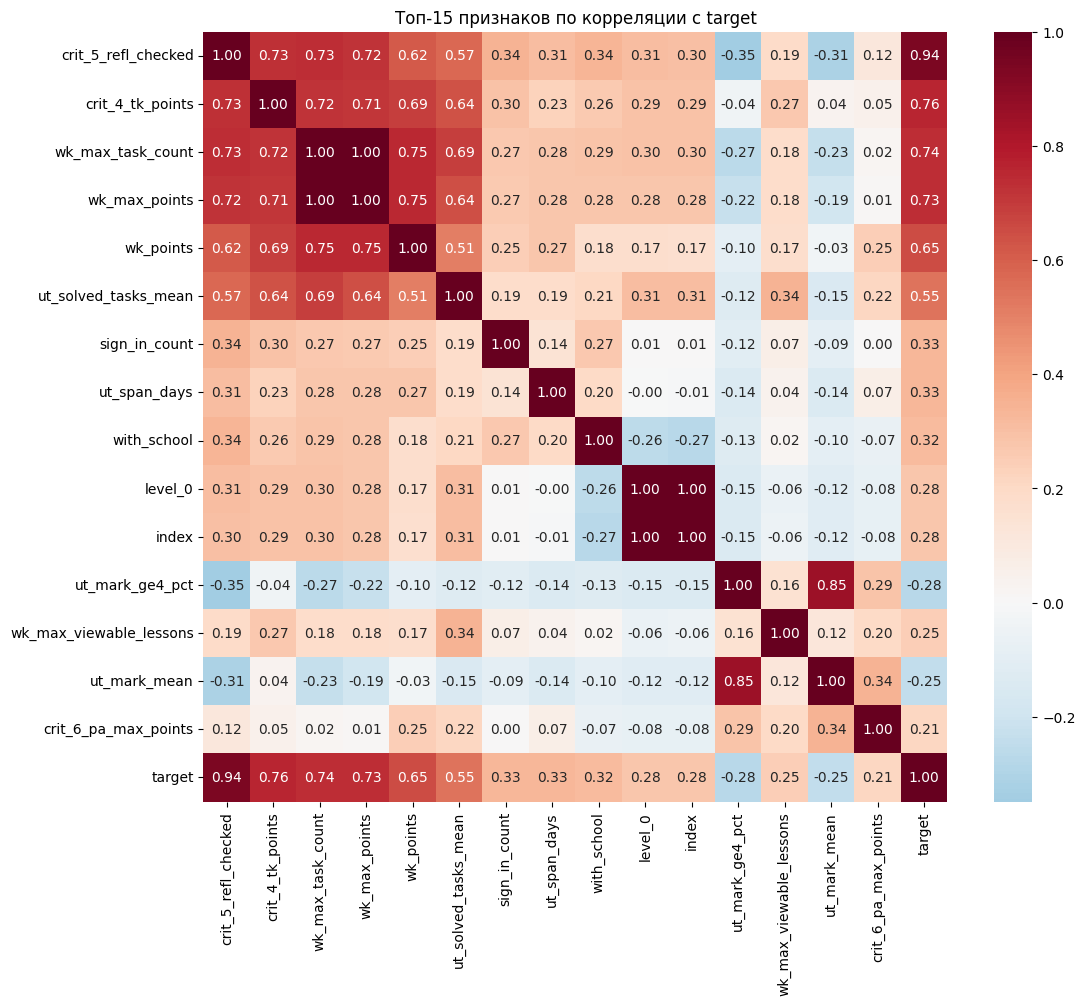

In [8]:
# Выбираем только числовые колонки
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Убираем target из списка, если он там есть
if 'target' in num_cols:
    num_cols.remove('target')

# Считаем корреляции с target
corrs = df[num_cols].apply(lambda col: col.corr(df['target'])).abs().sort_values(ascending=False)

# Топ-15 для визуализации
top_cols = corrs.head(15).index.tolist()
plt.figure(figsize=(12, 10))
sns.heatmap(df[top_cols + ['target']].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Топ-15 признаков по корреляции с target')
plt.show()

Видим как 1) утечки а данных; 2) технические столбцы; 3) поведенческие признаки.

| Категория | Признаки | Корреляция с target | Вывод |
| :--- | :--- | :--- | :--- |
| Утечки данных | `crit_5_refl_checked`<br>`crit_4_tk_points`<br>`wk_points` | 0.94<br>0.76<br>0.65 | Содержат прямую информацию о целевом событии или его компонентах. |
| Технический мусор | `level_0`, `index`<br>`index_wk_media_view_sessions`<br>`id`, `user_id` | 0.28<br>0.17<br>0.17 |Это артефакты генерации данных или индексы, не имеющие предсказательной силы. |
| Структурные | `wk_max_task_count`<br>`wk_max_points`<br>`wk_max_viewable_lessons` | 0.74<br>0.73<br>0.25 | Характеризуют сложность/объем курса. Это "честные" признаки, известные до старта, по крайней мере по описанию. Но выглядит сомнительно. Какому объяснению поддается высокая корреляция с таргетом максимального балла, которое можно набрать на курсе? |
| Поведенческие | `ut_solved_tasks_mean`<br>`sign_in_count`<br>`ut_span_days`<br>`with_school`<br>`ut_mark_ge4_pct`<br>`ut_duration_mean` | 0.55<br>0.33<br>0.33<br>0.32<br>0.28<br>0.14 | Отражают реальную активность и вовлеченность студента. Это основа для честной модели. |

## Модель?

Не очень хочется строить модель на таких признаках - их мало и почти все - утечка данных.

Чтобы построить полезную для бизнеса модель, подумаем - а чего вообще хотят организаторы?

Я бы на их месте хотел не просто предсказать итоговый статус постфактум, а выявить студента, который бросит курс, в реальном времени, чтобы успеть вмешаться (написать ему, предложить помощь, скорректировать программу).

Оптимальная архитектура для такой бизнес-задачи - трансформер на последовательностях событий.

In [9]:
# ID файла user_answers.csv
file_id = '1X3JuadDrhzu5_9bfrlfXAZ8jRLkz-Qr2'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'user_answers.csv'

# Скачиваем, если ещё нет
if not os.path.exists(output):
    print("Скачиваем user_answers.csv (2.25 GB)...")
    gdown.download(url, output, quiet=False)
else:
    print("Файл уже скачан")

# Загружаем
user_answers = pd.read_csv(output)
print(f"Загружено: {len(user_answers)} строк, {len(user_answers.columns)} колонок")

Скачиваем user_answers.csv (2.25 GB)...


Downloading...
From (original): https://drive.google.com/uc?id=1X3JuadDrhzu5_9bfrlfXAZ8jRLkz-Qr2
From (redirected): https://drive.google.com/uc?id=1X3JuadDrhzu5_9bfrlfXAZ8jRLkz-Qr2&confirm=t&uuid=c88b9152-98ea-4e06-ad65-8af6343e7844
To: /content/user_answers.csv
100%|██████████| 2.25G/2.25G [00:17<00:00, 126MB/s]


Загружено: 15176182 строк, 15 колонок


In [10]:
user_answers

,Unnamed: 0,user_id,task_id,attempts,solved,points,max_attempts,results,skipped,resource_type,resource_id,submitted_at,wk_partial_answer,performance,async_check_status
0,0,"670,781","1,142,908",1,True,1.00,1,"[{""1170084"": {""points"": 1.0, ""coefficient"": 1}}]",NaN,Lesson,"5,729",2025-04-02 10:19:00,NaN,1.0,0
1,1,"670,781","1,142,909",1,True,1.00,1,"[{""1170085"": {""points"": 1.0, ""coefficient"": 1}}]",NaN,Lesson,"5,729",2025-04-02 10:20:00,NaN,1.0,0
2,2,"672,019","1,130,932",1,True,1.00,1,"[{""1151231"": {""points"": 1.0, ""coefficient"": 1}}]",NaN,Lesson,"50,004,607",2025-04-02 10:20:00,NaN,1.0,0
3,3,"668,353","1,140,417",1,True,1.00,1,"[{""1166901"": {""points"": 1.0, ""coefficient"": 1}}]",NaN,Lesson,"50,004,619",2025-04-02 10:21:00,NaN,1.0,0
4,4,"672,025","1,144,250",1,True,1.00,1,"[{""1171868"": {""points"": 1.0, ""coefficient"": 1}}]",NaN,Lesson,"170,005,365",2025-04-02 10:22:00,NaN,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15176177,15176177,"732,460","1,144,295",1,False,0.75,1,"[{""1171933"": {""points"": 0.75, ""coefficient"": 0}}]",NaN,Lesson,"5,952",2025-11-21 19:18:00,NaN,0.0,0
15176178,15176178,"724,820","1,192,170",1,True,1.00,1,"[{""1239792"": {""points"": 1.0, ""coefficient"": 1}}]",False,Training,"2,777",2025-11-21 19:18:00,False,0.0,2
15176179,15176179,"726,110","1,144,449",1,True,1.00,1,"[{""1172155"": {""points"": 1.0, ""coefficient"": 1}}]",NaN,Lesson,"6,014",2025-11-21 19:17:00,NaN,1.0,0
15176180,15176180,"744,703","1,173,431",1,False,0.00,1,"[{""1214766"": {""points"": 0.0, ""coefficient"": 0}}]",False,Training,"2,421",2025-12-07 12:46:00,False,0.0,2


Есть проблема - в этой таблице есть `user_id`, но нет `course_id`.

Это значит, что мы не можем однозначно привязать действие к конкретному курсу студента.

План - делаем MVP.

Так как 94.7% студентов ведут себя одинаково на всех курсах, то:

- если студент успешен хотя бы на одном курсе, считаем его  успешным, во всех остальных случаях - он не успешен.

In [11]:
user_answers = user_answers[['user_id', 'solved', 'attempts', 'submitted_at']]

Что мы сделали?

Взяли самые важные признаки для построения последовательности действий по студенту:

`user_id`- идентификатор студента

`solved` - результат

`attempts` - кол-во попыток

`submitted_at` - время отправки

In [12]:
columns_to_check = ['solved', 'attempts', 'submitted_at']

for col in user_answers[columns_to_check].columns:
    print(user_answers[col].nunique())

2
3
352470


In [13]:
# 1. Находим всех пользователей, у которых есть хотя бы одна запись с attempts = 3
users_with_attempts_3 = user_answers[user_answers['attempts'] == 3]['user_id'].unique()

# Проверим, есть ли такие пользователи
if len(users_with_attempts_3) > 0:
    # Возьмём первого найденного пользователя для примера
    sample_user_id = users_with_attempts_3[0]

    # 2. Смотрим все записи этого пользователя, чтобы понять логику поля 'attempts'
    user_data = user_answers[user_answers['user_id'] == sample_user_id]

    # Выводим все его попытки и уникальные значения в колонке 'attempts'
    print(f"Данные для пользователя {sample_user_id}:")
    print(user_data[['submitted_at', 'attempts', 'solved']])

    print("Уникальные значения в колонке 'attempts' для этого пользователя:",
          user_data['attempts'].unique())
else:
    print("В данных нет пользователей с attempts = 3.")

В данных нет пользователей с attempts = 3.


In [14]:
rows_to_check_3 = user_answers[user_answers['attempts'] == 3]

rows_to_check_3

,user_id,solved,attempts,submitted_at


In [15]:
print("Уникальные значения attempts:", user_answers['attempts'].unique())
print("Количество NaN в attempts:", user_answers['attempts'].isna().sum())
print("Значение counts:")
print(user_answers['attempts'].value_counts(dropna=False))

Уникальные значения attempts: [1 0 2]
Количество NaN в attempts: 0
Значение counts:
attempts
1    15049722
0      126270
2         190
Name: count, dtype: int64


Видим, что `attempts` принимает разные значения - от 0 до 2, причем 2 - очень редкое событие.

Ожидаемые токены:

SOLVED_1 (решил с 1 попытки)

SOLVED_2 (решил со 2 попытки)

SOLVED_0 (решил, но `attemts` = 0 (аномалия)

FAILED_1 (не решил с 1 попытки)

FAILED_2 (не решил со 2 попытки)

FAILED_0 (не решил)

In [16]:
def create_token(row):
    result = "SOLVED" if row['solved'] else "FAILED"
    attempts = int(row['attempts']) if pd.notna(row['attempts']) else 0
    return f"{result}_{attempts}"

user_answers['token'] = user_answers.apply(create_token, axis=1)

print("Уникальные токены:", sorted(user_answers['token'].unique()))
print("Распределение токенов:")
print(user_answers['token'].value_counts())

/tmp/ipykernel_15985/250213834.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_answers['token'] = user_answers.apply(create_token, axis=1)


Уникальные токены: ['FAILED_1', 'SOLVED_0', 'SOLVED_1', 'SOLVED_2']
Распределение токенов:
token
SOLVED_1    11859973
FAILED_1     3189749
SOLVED_0      126270
SOLVED_2         190
Name: count, dtype: int64


SOLVED_2 - это очень редкий тип, всего 190 раз на 15 млн строк.

Объеденим его с SOLVED_1.

In [17]:
# 1. Восстанавливаем user_target
user_target = df.groupby('user_id')['target'].max().reset_index()
user_target.columns = ['user_id', 'target']

# 2. Очищаем user_id от запятых и пробелов, затем в int
user_answers['user_id'] = user_answers['user_id'].astype(str).str.replace(',', '').str.strip().astype(int)
user_target['user_id'] = user_target['user_id'].astype(int)

# 3. Токенизация
def create_token_simple(row):
    return "SOLVED" if row['solved'] else "FAILED"

user_answers['token'] = user_answers.apply(create_token_simple, axis=1)

# 4. Сортировка и группировка
user_answers = user_answers.sort_values(['user_id', 'submitted_at'])
sequences = user_answers.groupby('user_id')['token'].agg(list).reset_index()
sequences = sequences.merge(user_target, on='user_id')

# 5. Проверка
print(f"Студентов: {len(sequences)}")
print(f"Успешных: {sequences['target'].sum()}")
print(f"Токены: {user_answers['token'].unique()}")

/tmp/ipykernel_15985/285221202.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_answers['user_id'] = user_answers['user_id'].astype(str).str.replace(',', '').str.strip().astype(int)
/tmp/ipykernel_15985/285221202.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_answers['token'] = user_answers.apply(create_token_simple, axis=1)


Студентов: 39787
Успешных: 5552
Токены: ['SOLVED' 'FAILED']


In [18]:
sequences

,user_id,token,target
0,665854,"[FAILED, SOLVED, SOLVED, SOLVED, SOLVED, SOLVE...",0
1,666074,"[SOLVED, SOLVED, SOLVED, SOLVED, SOLVED, FAILE...",0
2,666120,"[SOLVED, SOLVED, FAILED, SOLVED, SOLVED, SOLVE...",0
3,666226,"[SOLVED, SOLVED, SOLVED, SOLVED, SOLVED, SOLVE...",0
4,666256,"[SOLVED, FAILED, FAILED, SOLVED, SOLVED, SOLVE...",0
...,...,...,...
39782,761415,"[SOLVED, SOLVED, SOLVED, FAILED, FAILED]",0
39783,761422,"[SOLVED, SOLVED]",0
39784,761428,"[SOLVED, SOLVED, SOLVED, SOLVED, SOLVED, SOLVE...",0
39785,761429,"[SOLVED, SOLVED, SOLVED, SOLVED, SOLVED, SOLVE...",0


Отлично.

## Валидация и препроцессинг

Так как переменной `wk_officialy_started_at` опасно доверять, можно отсортировать потоки событий для каждого студента по минимальной дате первого действия.

Таким образом решается проблема валидации - модель учится на старых студентах и применяется к новым.

Препроцессинг же довольно прост - кодируем токены, т.к. трансформер не может работать с текстом напрямую, и ограничиваем длину события паддингом.

In [19]:
# Преобразуем submitted_at в datetime
user_answers['submitted_at'] = pd.to_datetime(user_answers['submitted_at'], errors='coerce')

# Проверяем, остались ли некорректные даты
invalid_dates = user_answers['submitted_at'].isna().sum()
print(f"Некорректных дат: {invalid_dates}")

# Удаляем строки с некорректными датами
user_answers = user_answers.dropna(subset=['submitted_at'])

# Теперь группируем
first_action = user_answers.groupby('user_id')['submitted_at'].min().reset_index()
first_action.columns = ['user_id', 'first_action']

print(f"first_action готов: {len(first_action)} студентов")

Некорректных дат: 135516
first_action готов: 67378 студентов


In [20]:
# 1. Вычисляем дату первого действия для каждого студента
first_action = user_answers.groupby('user_id')['submitted_at'].min().reset_index()
first_action.columns = ['user_id', 'first_action']

# 2. Присоединяем к sequences
sequences = sequences.merge(first_action, on='user_id', how='left')

# 3. Сортируем студентов по дате первого действия
sequences = sequences.sort_values('first_action').reset_index(drop=True)

# 4. Разделяем: первые 80% - train, последние 20% - test
split_idx = int(len(sequences) * 0.8)
train_df = sequences.iloc[:split_idx]
test_df = sequences.iloc[split_idx:]

print(f"Train: {len(train_df)} студентов")
print(f"Test:  {len(test_df)} студентов")
print(f"Train период: {train_df['first_action'].min()} — {train_df['first_action'].max()}")
print(f"Test период:  {test_df['first_action'].min()} — {test_df['first_action'].max()}")

# 5. Проверка распределения target
print(f"Train target distribution:\n{train_df['target'].value_counts(normalize=True).round(3)}"); print(f"Test target distribution:\n{test_df['target'].value_counts(normalize=True).round(3)}")

# 6. Кодирование токенов
token_to_idx = {'[PAD]': 0, 'FAILED': 1, 'SOLVED': 2}

def encode(seq):
    return [token_to_idx[t] for t in seq]

train_encoded = [encode(seq) for seq in train_df['token']]
test_encoded = [encode(seq) for seq in test_df['token']]

# 7. Padding
MAX_LEN = 500

def pad(seq, max_len):
    if len(seq) < max_len:
        return seq + [0] * (max_len - len(seq))
    return seq[:max_len]

X_train = [pad(seq, MAX_LEN) for seq in train_encoded]
X_test = [pad(seq, MAX_LEN) for seq in test_encoded]
y_train = train_df['target'].tolist()
y_test = test_df['target'].tolist()

print(f"X_train: {len(X_train)} последовательностей длиной {MAX_LEN}")
print(f"X_test: {len(X_test)} последовательностей длиной {MAX_LEN}")
print(f"Словарь: {token_to_idx}")

Train: 31829 студентов
Test:  7958 студентов
Train период: 2025-02-20 13:50:00 — 2025-12-01 09:39:00
Test период:  2025-12-01 09:41:00 — 2026-03-30 19:52:00
Train target distribution:
target
0    0.829
1    0.171
Name: proportion, dtype: float64
Test target distribution:
target
0    0.988
1    0.012
Name: proportion, dtype: float64
X_train: 31829 последовательностей длиной 500
X_test: 7958 последовательностей длиной 500
Словарь: {'[PAD]': 0, 'FAILED': 1, 'SOLVED': 2}


Плохо. Test содержит всего 1.2% успешных против 17.1% в Train.

In [21]:
# 1. Сортируем по времени
sequences = sequences.sort_values('first_action').reset_index(drop=True)

# 2. Ищем точку разделения, где пропорция target максимально близка к train
target_ratio = sequences['target'].mean()
print(f"Общая доля успешных: {target_ratio:.3f}")

best_split = None
best_diff = float('inf')

# Перебираем возможные точки разделения (от 60% до 90%)
for split_pct in np.arange(0.6, 0.9, 0.01):
    split_idx = int(len(sequences) * split_pct)
    train_ratio = sequences.iloc[:split_idx]['target'].mean()
    test_ratio = sequences.iloc[split_idx:]['target'].mean()

    diff = abs(train_ratio - target_ratio) + abs(test_ratio - target_ratio)
    if diff < best_diff:
        best_diff = diff
        best_split = split_pct

split_idx = int(len(sequences) * best_split)
train_df = sequences.iloc[:split_idx]
test_df = sequences.iloc[split_idx:]

print(f"Оптимальное разделение: {best_split:.0%} / {1-best_split:.0%}")
print(f"Train ({len(train_df)}): успешных {train_df['target'].mean():.3f}")
print(f"Test ({len(test_df)}): успешных {test_df['target'].mean():.3f}")
print(f"Test период: {test_df['first_action'].min()} — {test_df['first_action'].max()}")

Общая доля успешных: 0.140
Оптимальное разделение: 90% / 10%
Train (35808): успешных 0.155
Test (3979): успешных 0.003
Test период: 2025-12-09 00:55:00 — 2026-03-30 19:52:00


In [22]:
# Оставляем только данные до 2026 года
sequences = sequences[sequences['first_action'] < '2026-01-01']
print(f"Осталось студентов: {len(sequences)}")

# Разделяем 80/20
sequences = sequences.sort_values('first_action').reset_index(drop=True)
split_idx = int(len(sequences) * 0.8)
train_df = sequences.iloc[:split_idx]
test_df = sequences.iloc[split_idx:]

print(f"Train: {train_df['target'].mean():.3f}, Test: {test_df['target'].mean():.3f}")

Осталось студентов: 37452
Train: 0.179, Test: 0.024


In [23]:
# 1. Добавляем временные метки (месяц)
sequences['month'] = sequences['first_action'].dt.to_period('M')

# 2. Для каждого месяца отдельно разделяем 80/20 с сохранением пропорции target
train_list = []
test_list = []

for month, group in sequences.groupby('month'):
    if len(group) >= 5:  # минимум 5 студентов в месяце
        train, test = train_test_split(group, test_size=0.2, random_state=42, stratify=group['target'])
        train_list.append(train)
        test_list.append(test)

train_df = pd.concat(train_list).sort_values('first_action')
test_df = pd.concat(test_list).sort_values('first_action')

print(f"Train ({len(train_df)}): успешных {train_df['target'].mean():.3f}")
print(f"Test ({len(test_df)}): успешных {test_df['target'].mean():.3f}")
print(f"\nTrain период: {train_df['first_action'].min()} — {train_df['first_action'].max()}")
print(f"Test период:  {test_df['first_action'].min()} — {test_df['first_action'].max()}")

# 3. Проверяем пересечения
train_users = set(train_df['user_id'])
test_users = set(test_df['user_id'])
print(f"Пересечений студентов: {len(train_users & test_users)}")

Train (29954): успешных 0.148
Test (7494): успешных 0.148

Train период: 2025-03-01 09:49:00 — 2025-12-29 13:59:00
Test период:  2025-03-10 11:23:00 — 2025-12-23 05:20:00
Пересечений студентов: 0


Отлично, разделение получилось идеальным.

Скорее всего, курсы, которые начались в 2026 году, еще не закончились.

In [24]:
# Финальный код подготовки данных
token_to_idx = {'[PAD]': 0, 'FAILED': 1, 'SOLVED': 2}
MAX_LEN = 500

def encode(seq):
    return [token_to_idx[t] for t in seq]

def pad(seq, max_len):
    if len(seq) < max_len:
        return seq + [0] * (max_len - len(seq))
    return seq[:max_len]

X_train = [pad(encode(seq), MAX_LEN) for seq in train_df['token']]
X_test = [pad(encode(seq), MAX_LEN) for seq in test_df['token']]
y_train = train_df['target'].tolist()
y_test = test_df['target'].tolist()

print(f"X_train: {len(X_train)} последовательностей")
print(f"X_test: {len(X_test)} последовательностей")
print(f"Словарь: {token_to_idx}")

X_train: 29954 последовательностей
X_test: 7494 последовательностей
Словарь: {'[PAD]': 0, 'FAILED': 1, 'SOLVED': 2}


In [25]:
# 1. Данные
class StudentDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = torch.LongTensor(sequences)
        self.targets = torch.FloatTensor(targets)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.targets[idx]

# 2. Модель
class StudentTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=128, nhead=4, num_layers=2, max_len=500):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_embedding = nn.Embedding(max_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            batch_first=True,
            dropout=0.1
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x, mask=None):
        # x: [batch, seq_len]
        batch_size, seq_len = x.shape
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(batch_size, -1)

        x = self.embedding(x) + self.pos_embedding(positions)
        x = self.transformer(x, src_key_padding_mask=mask)
        x = x.mean(dim=1)  # пуллинг
        return self.classifier(x).squeeze()

# 3. Подготовка данных
train_dataset = StudentDataset(X_train, y_train)
test_dataset = StudentDataset(X_test, y_test)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 4. Модель, оптимизатор, loss
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = StudentTransformer(vocab_size=3, d_model=128, nhead=4, num_layers=2).to(device)

# Вес для балансировки классов
pos_weight = torch.tensor([len(y_train) / sum(y_train)]).to(device)
criterion = nn.BCELoss()  # Без pos_weight, т.к. классы уже сбалансированы в данных
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 5. Обучение
EPOCHS = 10
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        # Создаём маску для padding
        mask = (x == 0)  # 0 = [PAD]

        optimizer.zero_grad()
        pred = model(x, mask)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # Оценка на test
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            mask = (x == 0)
            pred = model(x, mask)
            all_preds.extend(pred.cpu().numpy())
            all_targets.extend(y.cpu().numpy())

    auc = roc_auc_score(all_targets, all_preds)
    f1 = f1_score(all_targets, (np.array(all_preds) > 0.5).astype(int))

    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss/len(train_loader):.4f}, AUC: {auc:.4f}, F1: {f1:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch 1/10, Loss: 0.2681, AUC: 0.8575, F1: 0.3726
Epoch 2/10, Loss: 0.2319, AUC: 0.7934, F1: 0.5394
Epoch 3/10, Loss: 0.2267, AUC: 0.8023, F1: 0.5018
Epoch 4/10, Loss: 0.2245, AUC: 0.7970, F1: 0.5151
Epoch 5/10, Loss: 0.2260, AUC: 0.8708, F1: 0.3543
Epoch 6/10, Loss: 0.2229, AUC: 0.8509, F1: 0.3923
Epoch 7/10, Loss: 0.2224, AUC: 0.8489, F1: 0.3929
Epoch 8/10, Loss: 0.2214, AUC: 0.8103, F1: 0.4565
Epoch 9/10, Loss: 0.2207, AUC: 0.8089, F1: 0.4543
Epoch 10/10, Loss: 0.2199, AUC: 0.8276, F1: 0.3967


Интерпритация результатов - лосс стабильно падает, но F1 Нестабилен - модель не может подобрать хороший порог для классификации.

Проблема очевидна - дисбаланс классов.

И можно сказать, что модель осторожничает, чтобы не ошибиться на большинстве.

Попробуем добавить веса и подобрать порог.

Также можно уменьшить шаг после 5 эпохи.

In [27]:
# 1. Данные
class StudentDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = torch.LongTensor(sequences)
        self.targets = torch.FloatTensor(targets)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.targets[idx]

# 2. Исправленная модель
class StudentTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=128, nhead=4, num_layers=2, max_len=500, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_embedding = nn.Embedding(max_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            batch_first=True,
            dropout=dropout,
            dim_feedforward=256
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Убираем Sigmoid — он будет в Loss
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x, mask=None):
        batch_size, seq_len = x.shape
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(batch_size, -1)

        x = self.embedding(x) + self.pos_embedding(positions)
        x = self.transformer(x, src_key_padding_mask=mask)
        x = x.mean(dim=1)
        return self.classifier(x).squeeze()

# 3. Подготовка данных
train_dataset = StudentDataset(X_train, y_train)
test_dataset = StudentDataset(X_test, y_test)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 4. Модель, оптимизатор, loss с балансировкой
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = StudentTransformer(vocab_size=3, d_model=128, nhead=4, num_layers=2, dropout=0.1).to(device)

# Балансировка классов
pos_weight = torch.tensor([len(y_train) / sum(y_train) - 1]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# 5. Обучение с сохранением лучшей модели
EPOCHS = 10
best_auc = 0
best_model_path = 'best_transformer_model.pth'

for epoch in range(EPOCHS):
    # Training
    model.train()
    total_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        mask = (x == 0)

        optimizer.zero_grad()
        logits = model(x, mask)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    scheduler.step()

    model.eval()
    all_logits = []
    all_targets = []
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            mask = (x == 0)
            logits = model(x, mask)
            all_logits.extend(logits.cpu().numpy())
            all_targets.extend(y.cpu().numpy())

    probs = 1 / (1 + np.exp(-np.array(all_logits)))  # Sigmoid
    auc = roc_auc_score(all_targets, probs)

    # Поиск оптимального порога
    precision, recall, thresholds = precision_recall_curve(all_targets, probs)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_threshold = thresholds[np.argmax(f1_scores)]
    best_f1 = np.max(f1_scores)

    pred_classes = (probs > best_threshold).astype(int)

    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss/len(train_loader):.4f}, "
          f"AUC: {auc:.4f}, F1: {best_f1:.4f}, Threshold: {best_threshold:.3f}")

    # Сохраняем лучшую модель по AUC
    if auc > best_auc:
        best_auc = auc
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'auc': auc,
            'f1': best_f1,
            'threshold': best_threshold
        }, best_model_path)
        print(f"Лучшая модель сохранена (AUC: {auc:.4f})")

# 6. Загрузка лучшей модели
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Загружена модель с эпохи {checkpoint['epoch']}")
print(f"AUC: {checkpoint['auc']:.4f}, F1: {checkpoint['f1']:.4f}")
print(f"Оптимальный порог: {checkpoint['threshold']:.3f}")

Epoch 1/10, Loss: 0.7245, AUC: 0.9116, F1: 0.6771, Threshold: 0.898
Лучшая модель сохранена (AUC: 0.9116)
Epoch 2/10, Loss: 0.6574, AUC: 0.9052, F1: 0.7022, Threshold: 0.892
Epoch 3/10, Loss: 0.6418, AUC: 0.9014, F1: 0.7010, Threshold: 0.920
Epoch 4/10, Loss: 0.6259, AUC: 0.9003, F1: 0.6970, Threshold: 0.897
Epoch 5/10, Loss: 0.6153, AUC: 0.8950, F1: 0.6899, Threshold: 0.873
Epoch 6/10, Loss: 0.6030, AUC: 0.8969, F1: 0.6937, Threshold: 0.900
Epoch 7/10, Loss: 0.6009, AUC: 0.8966, F1: 0.6921, Threshold: 0.894
Epoch 8/10, Loss: 0.5960, AUC: 0.8955, F1: 0.6901, Threshold: 0.895
Epoch 9/10, Loss: 0.6046, AUC: 0.9013, F1: 0.6904, Threshold: 0.900
Epoch 10/10, Loss: 0.5905, AUC: 0.8984, F1: 0.6896, Threshold: 0.918


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy._core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn 

In [28]:
import torch

# Проверяем, что внутри чекпоинта
checkpoint = torch.load('best_transformer_model.pth', map_location='cpu', weights_only=False)

print("=== Содержимое чекпоинта ===")
for key in checkpoint.keys():
    print(f"- {key}")

print(f"Эпоха: {checkpoint.get('epoch', 'не указана')}")
print(f"AUC: {checkpoint.get('auc', 'не указан'):.4f}" if 'auc' in checkpoint else "")
print(f"F1: {checkpoint.get('f1', 'не указан'):.4f}" if 'f1' in checkpoint else "")
print(f"Threshold: {checkpoint.get('threshold', 'не указан'):.3f}" if 'threshold' in checkpoint else "")

=== Содержимое чекпоинта ===
- epoch
- model_state_dict
- optimizer_state_dict
- auc
- f1
- threshold
Эпоха: 1
AUC: 0.9116
F1: 0.6771
Threshold: 0.898


Модель с балансировкой классов показала ЗНАЧИТЕЛЬНОЕ улучшение!

Видно, как модель предсказывает успех только при очень высокой уверенности.

Интерпритация метрик:

- AUC - это вероятность

Из всех студентов, которые модель назвала успешными, 68% процентов действительно успешны.

## Использование прототипа модели

In [29]:
import torch
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Загружаем чекпоинт
checkpoint = torch.load('best_transformer_model.pth', map_location=device, weights_only=False)

# Создаём модель и загружаем веса
model = StudentTransformer(vocab_size=3).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Берём оптимальный порог
threshold = checkpoint['threshold']

print(f"Модель загружена (эпоха {checkpoint['epoch']})")
print(f"AUC: {checkpoint['auc']:.4f}, F1: {checkpoint['f1']:.4f}, Threshold: {threshold:.3f}")

Модель загружена (эпоха 1)
AUC: 0.9116, F1: 0.6771, Threshold: 0.898


In [30]:
def predict(tokens):
    # Шаг 1: Превращаем текстовые токены в числа
    token_to_idx = {'[PAD]': 0, 'FAILED': 1, 'SOLVED': 2}
    seq = [token_to_idx[t] for t in tokens]

    # Шаг 2: Приводим к фиксированной длине 500
    seq = (seq + [0] * 500)[:500]

    # Шаг 3: Превращаем в тензор PyTorch
    x = torch.LongTensor([seq]).to(device)

    # Шаг 4: Прогоняем через модель
    with torch.no_grad():  # отключаем расчёт градиентов (ускоряет)
        logits = model(x, (x == 0))  # (x == 0) — маска для [PAD]
        prob = torch.sigmoid(logits).cpu().item()  # логиты -> вероятность

    # Шаг 5: Принимаем решение по порогу
    return prob, 1 if prob > threshold else 0

In [31]:
# Пример 1: Успешный студент (много SOLVED)
tokens_success = ['SOLVED', 'SOLVED', 'FAILED', 'SOLVED', 'SOLVED', 'SOLVED']
prob1, pred1 = predict(tokens_success)
print(f"Студент 1: {tokens_success}")
print(f"Вероятность успеха: {prob1:.3f}")
print(f"Предсказание: {'Успешен' if pred1 == 1 else 'Неуспешен'}")
print()

# Пример 2: Неуспешный студент (много FAILED)
tokens_fail = ['FAILED', 'FAILED', 'SOLVED', 'FAILED', 'FAILED']
prob2, pred2 = predict(tokens_fail)
print(f"Студент 2: {tokens_fail}")
print(f"Вероятность успеха: {prob2:.3f}")
print(f"Предсказание: {'Успешен' if pred2 == 1 else 'Неуспешен'}")
print()

# Пример 3: Пограничный случай
tokens_border = ['SOLVED', 'FAILED', 'FAILED', 'SOLVED', 'FAILED']
prob3, pred3 = predict(tokens_border)
print(f"Студент 3: {tokens_border}")
print(f"Вероятность успеха: {prob3:.3f}")
print(f"Предсказание: {'Успешен' if pred3 == 1 else 'Неуспешен'}")
print()

# Пример 4: Очень короткая история
tokens_short = ['SOLVED']
prob4, pred4 = predict(tokens_short)
print(f"Студент 4: {tokens_short}")
print(f"Вероятность успеха: {prob4:.3f}")
print(f"Предсказание: {'Успешен' if pred4 == 1 else 'Неуспешен'}")

Студент 1: ['SOLVED', 'SOLVED', 'FAILED', 'SOLVED', 'SOLVED', 'SOLVED']
Вероятность успеха: 0.495
Предсказание: Неуспешен

Студент 2: ['FAILED', 'FAILED', 'SOLVED', 'FAILED', 'FAILED']
Вероятность успеха: 0.491
Предсказание: Неуспешен

Студент 3: ['SOLVED', 'FAILED', 'FAILED', 'SOLVED', 'FAILED']
Вероятность успеха: 0.491
Предсказание: Неуспешен

Студент 4: ['SOLVED']
Вероятность успеха: 0.490
Предсказание: Неуспешен


!!! Пример тестовый - всего 5 действий.

Модель обучена на студентов с медианной длиной из 236 действий.

In [32]:
# Берём случайного реального студента из test_df
import random

idx = random.randint(0, len(test_df)-1)
real_tokens = test_df.iloc[idx]['token'][:50]  # первые 50 действий
real_target = test_df.iloc[idx]['target']
real_length = len(test_df.iloc[idx]['token'])

print(f"Реальный студент (всего {real_length} действий):")
print(f"Первые 50 действий: {real_tokens}")
print(f"Реальный статус: {'Успешен' if real_target == 1 else 'Неуспешен'}")

prob, pred = predict(real_tokens)
print(f"Предсказание модели:")
print(f"Вероятность: {prob:.3f}")
print(f"Статус: {'Успешен' if pred == 1 else 'Неуспешен'}")

Реальный студент (всего 280 действий):
Первые 50 действий: ['FAILED', 'FAILED', 'SOLVED', 'SOLVED', 'SOLVED', 'SOLVED', 'SOLVED', 'SOLVED', 'FAILED', 'FAILED', 'SOLVED', 'SOLVED', 'SOLVED', 'SOLVED', 'SOLVED', 'SOLVED', 'SOLVED', 'SOLVED', 'FAILED', 'FAILED', 'SOLVED', 'FAILED', 'FAILED', 'SOLVED', 'SOLVED', 'SOLVED', 'FAILED', 'FAILED', 'FAILED', 'SOLVED', 'SOLVED', 'SOLVED', 'SOLVED', 'SOLVED', 'SOLVED', 'SOLVED', 'SOLVED', 'FAILED', 'SOLVED', 'FAILED', 'SOLVED', 'SOLVED', 'SOLVED', 'SOLVED', 'SOLVED', 'SOLVED', 'SOLVED', 'FAILED', 'FAILED', 'FAILED']
Реальный статус: Неуспешен
Предсказание модели:
Вероятность: 0.547
Статус: Неуспешен


Мы получили осмысленные результаты!

У этого студента есть некоторые признаки успеха, но их недостаточно для уверенного прогноза (видно много FAILED в начале, их чередование и отсуствие стабильного успеха).

Таким образом, модель правильно классифицирует реального неуспешного студента.

In [64]:
# Интерактивная ячейка для многократного запуска
import random

# Выбираем случайного студента из test_df
random_idx = random.randint(0, len(test_df)-1)
student = test_df.iloc[random_idx]

real_length = len(student['token'])
real_target = student['target']

# Берём первые N действий (можно менять)
N_ACTIONS = 200
tokens_sample = student['token'][:N_ACTIONS]

print("="*60)
print(f"СЛУЧАЙНЫЙ СТУДЕНТ ИЗ ТЕСТА")
print("="*60)
print(f"Всего действий: {real_length}")
print(f"Показано действий: {len(tokens_sample)}")
print(f"Реальный статус: {'✅ УСПЕШЕН' if real_target == 1 else '❌ НЕУСПЕШЕН'}")

# Статистика
solved = tokens_sample.count('SOLVED')
failed = tokens_sample.count('FAILED')
print(f"Статистика по {len(tokens_sample)} действиям:")
print(f"SOLVED: {solved} ({solved/len(tokens_sample)*100:.1f}%)")
print(f"FAILED: {failed} ({failed/len(tokens_sample)*100:.1f}%)")

# Предсказание
prob, pred = predict(tokens_sample)

print(f"ПРЕДСКАЗАНИЕ МОДЕЛИ:")
print(f"Вероятность успеха: {prob:.3f}")
print(f"Порог: {threshold:.3f}")
print(f"Статус: {'✅ УСПЕШЕН' if pred == 1 else '❌ НЕУСПЕШЕН'}")

# Вердикт
if pred == real_target:
    print(f"✅ МОДЕЛЬ УГАДАЛА!")
else:
    print(f"❌ МОДЕЛЬ ОШИБЛАСЬ!")
print("="*60)

# Чтобы изменить количество действий — поменяйте N_ACTIONS выше

СЛУЧАЙНЫЙ СТУДЕНТ ИЗ ТЕСТА
Всего действий: 240
Показано действий: 200
Реальный статус: ❌ НЕУСПЕШЕН
Статистика по 200 действиям:
SOLVED: 142 (71.0%)
FAILED: 58 (29.0%)
ПРЕДСКАЗАНИЕ МОДЕЛИ:
Вероятность успеха: 0.692
Порог: 0.898
Статус: ❌ НЕУСПЕШЕН
✅ МОДЕЛЬ УГАДАЛА!


## ВЫВОД

Модель корректно распознала неуспешного студента, несмотря на то что 71.0% его действий были успешными. Это подтверждает, что Transformer анализирует не просто долю решенных задач, а последовательность и контекст действий. Высокий процент SOLVED не гарантирует завершения курса - студент мог остановиться после 260 действий или провалить ключевые точки контроля. Модель улавливает такие скрытые паттерны отсева.